## Building Models for Building Energy Prediction

## Table of Contents
*  
    * [Part 1 : Data Loading, Transformation and Exploration](#part-1)
    * [Part 2 : Feature extraction and ML training](#part-2)
    * [Part 3 : Hyperparameter Tuning and Model Optimisation](#part-3)
    


# Part 1: Data Loading, Transformation and Exploration <a class="anchor" name="part-1"></a>
## 1.1 Data Loading
In this section, you must load the given datasets into PySpark DataFrames and use DataFrame functions to process the data. For plotting, various visualisation packages can be used, but please ensure that you have included instructions to install the additional packages and that the installation will be successful in the provided Docker container (in case your marker needs to clear the notebook and rerun it).

### 1.1.1 Data Loading <a class="anchor" name="1.1"></a>
1.1.1 Write the code to create a SparkSession. For creating the SparkSession, you need to use a SparkConf object to configure the Spark app with a proper application name, to ensure the maximum partition size does not exceed 32MB, and to run locally with all CPU cores on your machine

### 1.1.1 Spark Session Setup

I  begin by creating a **Spark session** which serves as the entry point for all Spark operations.  
To optimise performance for our dataset, I customised the configuration with:

- `local[*]`: Utilises all available CPU cores on the machine.  
- `spark.sql.files.maxPartitionBytes = 32MB`: Controls maximum partition size for better load balancing.  
- `spark.driver.memory = 6g` and `spark.executor.memory = 6g`: Allocates sufficient memory for both driver and executors to handle large datasets.  
- `spark.executor.cores = 4`: Enables parallel execution within each executor.  

This setup ensures Spark is efficiently tuned for processing the building energy dataset in Assignment 2A.


In [1]:
# ==========================================
# 1.1.1 Spark Session Setup
# ==========================================
# Import Spark classes
from pyspark.sql import SparkSession
from pyspark import SparkConf

# Configure Spark with custom settings
conf = (
    SparkConf()
    .setAppName("FIT5202-A2A-BuildingEnergy")   # Set application name
    .setMaster("local[*]")                      # Use all available CPU cores
    .set("spark.sql.files.maxPartitionBytes", str(32*1024*1024))  # Limit partition size to 32MB
    .set("spark.driver.memory", "6g")           # Allocate 6 GB RAM to Spark driver
    .set("spark.executor.memory", "6g")         # Allocate 6 GB RAM per executor
    .set("spark.executor.cores", "4")           # Use 4 CPU cores per executor
)

# Create SparkSession with the above configuration
spark = SparkSession.builder.config(conf=conf).getOrCreate()

# Display Spark session details (for verification)
spark


1.1.2 Write code to define the schemas for the datasets, following the data types suggested in the metadata file. 

### Define Schemas for the Datasets

In this step, I explicitly defined the **schemas** for all three datasets instead of relying on Spark’s automatic type inference. This ensures:
- **Correct data types** are applied consistently across the datasets.
- **Better performance** because Spark does not need to scan files to guess column types.
- **Data quality control**, since inappropriate values will cause errors rather than being silently misinterpreted.

The schema design follows the metadata description in the assignment specification, with adjustments based on the raw CSV values to preserve precision:

- **meters.csv**
  - `building_id` (Integer) → foreign key to buildings.
  - `meter_type` (String) → categorical meter type (`e`, `c`, `s`, `h`).
  - `ts` (Timestamp) → time of reading.
  - `value` (**Double**) → energy consumption value. Changed from `Decimal(18,3)` to `Double` to handle values with more than 3 decimal places (e.g., `19.3427`).
  - `row_id` (Integer) → unique identifier.

- **building_information.csv**
  - Includes `site_id`, `building_id`, `primary_use`, `square_feet`, `floor_count`, `year_built`.
  - Three latent variables (`latent_y`, `latent_s`, `latent_r`) are stored as **Double** because they contain floating-point values with many decimal places. Using `Double` prevents rounding or truncation.

- **weather.csv**
  - `site_id` and `timestamp` identify the site and time of measurement.
  - All weather features (`air_temperature`, `cloud_coverage`, `dew_temperature`, `sea_level_pressure`, `wind_direction`, `wind_speed`) are defined as **Double**.  
    - This change ensures that values like `4.0` (for `cloud_coverage`) and `360.0` (for `wind_direction`) are parsed correctly.  
    - It also makes the dataset directly compatible with Spark MLlib’s `Imputer`, which requires `DoubleType`.

By enforcing these schemas with appropriate numeric types, I preserve full precision and guarantee that the downstream data transformation and machine learning steps use the correct data types.


In [2]:
# ==========================================
# 1.1.2 Define Schemas for Input Datasets
# ==========================================
from pyspark.sql.types import (
    StructType, StructField, IntegerType, StringType, TimestampType, DoubleType
)

# --- meters.csv schema (energy consumption readings) ---
meters_schema = StructType([
    StructField("building_id", IntegerType(), False),    # Foreign key to buildings
    StructField("meter_type",  StringType(),  False),    # Type of meter (e, c, s, h)
    StructField("ts",          TimestampType(), False),  # Timestamp of reading
    StructField("value",       DoubleType(),   True),    # Energy consumption value
    StructField("row_id",      IntegerType(),  False),   # Unique row identifier
])

# --- building_information.csv schema (metadata about buildings) ---
buildings_schema = StructType([
    StructField("site_id",      IntegerType(), False),
    StructField("building_id",  IntegerType(), False),
    StructField("primary_use",  StringType(),  True),    # Building usage category
    StructField("square_feet",  IntegerType(), True),    # Size of building
    StructField("floor_count",  IntegerType(), True),    # Floors in building
    StructField("row_id",       IntegerType(), False),
    StructField("year_built",   IntegerType(), True),    # Construction year
    StructField("latent_y",     DoubleType(),  True),    # Latent features (float)
    StructField("latent_s",     DoubleType(),  True),
    StructField("latent_r",     DoubleType(),  True),
])

# --- weather.csv schema (site-level weather conditions) ---
weather_schema = StructType([
    StructField("site_id",            IntegerType(),   False),
    StructField("timestamp",          TimestampType(), False),
    StructField("air_temperature",    DoubleType(),    True),
    StructField("cloud_coverage",     DoubleType(),    True),
    StructField("dew_temperature",    DoubleType(),    True),
    StructField("sea_level_pressure", DoubleType(),    True),
    StructField("wind_direction",     DoubleType(),    True),
    StructField("wind_speed",         DoubleType(),    True),
])

# Print schemas in JSON format for verification
print("\nMeters Schema:")
print(meters_schema.json())

print("\nBuildings Schema:")
print(buildings_schema.json())

print("\nWeather Schema:")
print(weather_schema.json())



Meters Schema:
{"fields":[{"metadata":{},"name":"building_id","nullable":false,"type":"integer"},{"metadata":{},"name":"meter_type","nullable":false,"type":"string"},{"metadata":{},"name":"ts","nullable":false,"type":"timestamp"},{"metadata":{},"name":"value","nullable":true,"type":"double"},{"metadata":{},"name":"row_id","nullable":false,"type":"integer"}],"type":"struct"}

Buildings Schema:
{"fields":[{"metadata":{},"name":"site_id","nullable":false,"type":"integer"},{"metadata":{},"name":"building_id","nullable":false,"type":"integer"},{"metadata":{},"name":"primary_use","nullable":true,"type":"string"},{"metadata":{},"name":"square_feet","nullable":true,"type":"integer"},{"metadata":{},"name":"floor_count","nullable":true,"type":"integer"},{"metadata":{},"name":"row_id","nullable":false,"type":"integer"},{"metadata":{},"name":"year_built","nullable":true,"type":"integer"},{"metadata":{},"name":"latent_y","nullable":true,"type":"double"},{"metadata":{},"name":"latent_s","nullable":

1.1.3 Using your schemas, load the CSV files into separate data frames. Print the schemas of all data frames. 

### Load the CSV Datasets

In this step, I loaded the three datasets (`meters.csv`, `building_information.csv`, and `weather.csv`) into PySpark DataFrames using the explicit schemas defined in **Task 1.1.2**.  

Key details:
- I set `option("header", True)` so that the first row of each CSV file is treated as column names.  
- The predefined schemas ensure that Spark reads the columns with the **correct data types** rather than inferring them automatically.  
- I used a relative path (`DATA_DIR = "./"`) so the notebook can locate the files in the same directory where it is running.  
- After loading, I printed the schema of each DataFrame with `printSchema()` to confirm that the structures match the assignment specification.  

This step ensures the datasets are properly ingested into Spark and are ready for downstream transformation and feature engineering tasks in Section 1.2.



In [3]:
DATA_DIR = "./"   # Directory where the CSV files are located (relative path)

# --- Load meters.csv ---
meters_df = (
    spark.read.format("csv")          # specify CSV format
    .option("header", True)           # use first row as header
    .schema(meters_schema)            # enforce predefined schema
    .load(f"{DATA_DIR}meters.csv")    # load file
)

# --- Load building_information.csv ---
buildings_df = (
    spark.read.format("csv")
    .option("header", True)
    .schema(buildings_schema)
    .load(f"{DATA_DIR}building_information.csv")
)

# --- Load weather.csv ---
weather_df = (
    spark.read.format("csv")
    .option("header", True)
    .schema(weather_schema)
    .load(f"{DATA_DIR}weather.csv")
)

# --- Verify schemas to confirm structure matches assignment spec ---
print("Meters Dataset Schema:")
meters_df.printSchema()

print("\nBuildings Dataset Schema:")
buildings_df.printSchema()

print("\nWeather Dataset Schema:")
weather_df.printSchema()


Meters Dataset Schema:
root
 |-- building_id: integer (nullable = true)
 |-- meter_type: string (nullable = true)
 |-- ts: timestamp (nullable = true)
 |-- value: double (nullable = true)
 |-- row_id: integer (nullable = true)


Buildings Dataset Schema:
root
 |-- site_id: integer (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- primary_use: string (nullable = true)
 |-- square_feet: integer (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- row_id: integer (nullable = true)
 |-- year_built: integer (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)


Weather Dataset Schema:
root
 |-- site_id: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- air_temperature: double (nullable = true)
 |-- cloud_coverage: double (nullable = true)
 |-- dew_temperature: double (nullable = true)
 |-- sea_level_pressure: double (nullable = true)
 |-- wind_directio

### 1.2 Data Transformation to Create Features <a class="anchor" name="1.2"></a>
In this section, we primarily have three tasks:  
1.2.1 The dataset includes sensors with hourly energy measurements. However, as a grid operator, we don’t need this level of granularity and lowering it can reduce the amount of data we need to process. For each building, we will aggregate the metered energy consumption in 6-hour intervals (0:00-5:59, 6:00-11:59, 12:00-17:59, 18:00-23:59). This will be our target (label) column for this prediction. Perform the aggregation for each building.


### Down-sample meters to 6-hour intervals (target label)

**Requirement.** Aggregate hourly meter readings into **four 6-hour windows per day**:
- 00:00–05:59  
- 06:00–11:59  
- 12:00–17:59  
- 18:00–23:59  

**Approach.**
1. Extract `date` and `hour` from the timestamp `ts`.  
2. Compute `bucket = floor(hour/6)` → values {0,1,2,3}, representing the four required windows.  
3. Derive `window_start` by combining the `date` with the bucket start hour (0, 6, 12, 18). This ensures reproducible alignment with other time-based datasets (e.g., weather).  
4. `groupBy(building_id, window_start, bucket)` and aggregate with **sum(value)** to produce `consumption_6h`.  
5. Add a human-readable `six_hour_block` string that exactly matches the assignment’s required wording.  

**Why this is correct.**  
Using `floor(hour/6)` ensures hours `[0–5]`, `[6–11]`, `[12–17]`, `[18–23]` map precisely to the required windows. The explicit `window_start` timestamp guarantees stable joins with weather features later in the pipeline.


In [4]:
from pyspark.sql import functions as F

# --- Create 6-hour buckets and aggregate consumption per building ---------------
meters_6h = (
    meters_df
    # Extract date and hour from timestamp
    .withColumn("date", F.to_date("ts"))
    .withColumn("hour", F.hour("ts"))
    
    # Assign each hour to a 6-hour bucket: 0 (midnight–5), 1 (6–11), 2 (12–17), 3 (18–23)
    .withColumn("bucket", (F.col("hour")/6).cast("int"))
    
    # Compute the canonical start hour for each bucket (0, 6, 12, 18)
    .withColumn("bucket_start_hour", F.col("bucket")*6)
    
    # Build a deterministic timestamp representing the start of the 6-hour window
    .withColumn(
        "window_start",
        F.to_timestamp(
            F.concat_ws(
                " ",
                F.col("date").cast("string"),
                F.lpad(F.col("bucket_start_hour").cast("string"), 2, "0")
            )
        )
    )
    
    # Aggregate energy consumption within each 6-hour window
    .groupBy("building_id", "window_start", "bucket")
    .agg(F.sum(F.col("value").cast("double")).alias("consumption_6h"))
)

# --- Add human-readable labels for 6-hour blocks -------------------------------
meters_agg = (
    meters_6h
    .withColumn(
        "six_hour_block",
        F.when(F.col("bucket")==0, "00:00–05:59")
         .when(F.col("bucket")==1, "06:00–11:59")
         .when(F.col("bucket")==2, "12:00–17:59")
         .otherwise("18:00–23:59")
    )
    .select("building_id","window_start","six_hour_block","consumption_6h")
    .orderBy("building_id","window_start")
    .cache()
)

# Preview results
print("Sample rows:")
meters_agg.show(8, truncate=False)

print("\nCount by block:")
meters_agg.groupBy("six_hour_block").count().orderBy("six_hour_block").show()

print("Distinct buildings:", meters_agg.select("building_id").distinct().count())
print("Total 6h windows:", meters_agg.count())


Sample rows:
+-----------+-------------------+--------------+--------------+
|building_id|window_start       |six_hour_block|consumption_6h|
+-----------+-------------------+--------------+--------------+
|0          |2022-01-01 00:00:00|00:00–05:59   |0.0           |
|0          |2022-01-01 06:00:00|06:00–11:59   |0.0           |
|0          |2022-01-01 12:00:00|12:00–17:59   |0.0           |
|0          |2022-01-01 18:00:00|18:00–23:59   |0.0           |
|0          |2022-01-02 00:00:00|00:00–05:59   |0.0           |
|0          |2022-01-02 06:00:00|06:00–11:59   |0.0           |
|0          |2022-01-02 12:00:00|12:00–17:59   |0.0           |
|0          |2022-01-02 18:00:00|18:00–23:59   |0.0           |
+-----------+-------------------+--------------+--------------+
only showing top 8 rows


Count by block:
+--------------+------+
|six_hour_block| count|
+--------------+------+
|   00:00–05:59|355917|
|   06:00–11:59|355976|
|   12:00–17:59|355902|
|   18:00–23:59|355920|
+--------

### Exploratory Check for Building 0  

Because `building_id = 0` appeared frequently in the dataset, I ran targeted checks to validate its meter readings:  

1. **Raw Values** – Displayed the first 20 hourly records to see if values were consistent or contained anomalies (e.g., all zeros).  
2. **Meter Types** – Queried distinct `meter_type` entries for building 0 to confirm which utilities were measured (electric, chilled water, steam, hot water).  
3. **Aggregate Statistics** – Computed row counts, total consumption, and average consumption per `meter_type`.  
   - Totals near zero suggest **broken sensors or missing data**.  
   - Abnormally high/low averages compared to other buildings may indicate **outliers**.  

**Why this matters.**  
Spotting anomalies at this stage helps prevent misleading or meaningless data from entering the modeling pipeline. For example, if building 0 reports almost exclusively zeros, it could be dropped or imputed rather than allowed to bias the model.  


In [5]:
# =========================================================
# Diagnostic checks for Building 0 (possible anomalies)
# =========================================================

# 1. Look at the raw hourly meter readings for building 0
#    - This helps verify whether values are missing, zero, or unrealistic.
meters_df.filter(F.col("building_id") == 0).orderBy("ts").show(20, truncate=False)

# 2. Check which meter types are associated with building 0
#    - Useful for identifying if the building has all expected types (e.g., electric, chilled water, etc.)
meters_df.filter(F.col("building_id") == 0).select("meter_type").distinct().show()

# 3. Aggregate statistics by meter type for building 0
#    - Row count, total sum of values, and average value per meter
#    - This helps detect anomalies such as meters reporting only 0’s or unrealistic averages
meters_df.filter(F.col("building_id") == 0).groupBy("meter_type").agg(
    F.count("*").alias("rows"),
    F.sum("value").alias("total_value"),
    F.avg("value").alias("avg_value")
).show()


+-----------+----------+-------------------+-----+-------+
|building_id|meter_type|ts                 |value|row_id |
+-----------+----------+-------------------+-----+-------+
|0          |e         |2022-01-01 00:00:00|0.0  |8155191|
|0          |e         |2022-01-01 01:00:00|0.0  |8156579|
|0          |e         |2022-01-01 02:00:00|0.0  |8157964|
|0          |e         |2022-01-01 03:00:00|0.0  |8159351|
|0          |e         |2022-01-01 04:00:00|0.0  |8160739|
|0          |e         |2022-01-01 05:00:00|0.0  |8162127|
|0          |e         |2022-01-01 06:00:00|0.0  |8163514|
|0          |e         |2022-01-01 07:00:00|0.0  |8164901|
|0          |e         |2022-01-01 08:00:00|0.0  |8166287|
|0          |e         |2022-01-01 09:00:00|0.0  |8167674|
|0          |e         |2022-01-01 10:00:00|0.0  |8169061|
|0          |e         |2022-01-01 11:00:00|0.0  |8170449|
|0          |e         |2022-01-01 12:00:00|0.0  |8171837|
|0          |e         |2022-01-01 13:00:00|0.0  |817322

### Follow-up Check: Non-Zero 6-hour Windows for Building 0  

After confirming that `building_id = 0` contained mostly zero values, I inspected whether it had **any meaningful consumption** after 6-hour aggregation:  

- **Filter applied:** kept only rows with `consumption_6h > 0`.  
- **Result:** displayed the first 10 non-zero windows in chronological order.  

**Why this matters.**  
If the dataset contains only a handful of non-zero readings among mostly zeros, the building contributes little useful signal. Such cases may be better handled through **imputation or exclusion** to avoid skewing model training.  


In [6]:
# --- Check non-zero 6-hour windows for building 0 -------------------
# Purpose: Verify whether building 0 has any meaningful consumption values
# after aggregation to 6-hour windows.
# Steps:
# 1. Filter for building_id == 0
# 2. Keep only rows where consumption_6h > 0
# 3. Order chronologically by window_start
# 4. Display first 10 rows for inspection

meters_agg.filter(F.col("building_id") == 0) \
    .filter(F.col("consumption_6h") > 0) \
    .orderBy("window_start") \
    .show(10, truncate=False)


+-----------+-------------------+--------------+--------------+
|building_id|window_start       |six_hour_block|consumption_6h|
+-----------+-------------------+--------------+--------------+
|0          |2022-01-30 06:00:00|06:00–11:59   |43.6839       |
|0          |2022-01-31 00:00:00|00:00–05:59   |37.5408       |
|0          |2022-01-31 12:00:00|12:00–17:59   |52.5571       |
|0          |2022-04-08 12:00:00|12:00–17:59   |59.3827       |
|0          |2022-05-01 18:00:00|18:00–23:59   |448.0         |
|0          |2022-05-20 18:00:00|18:00–23:59   |1479.108      |
|0          |2022-05-21 00:00:00|00:00–05:59   |1500.95       |
|0          |2022-05-21 06:00:00|06:00–11:59   |1702.987      |
|0          |2022-05-21 12:00:00|12:00–17:59   |1792.404      |
|0          |2022-05-21 18:00:00|18:00–23:59   |1586.952      |
+-----------+-------------------+--------------+--------------+
only showing top 10 rows



### Temporal Validation for Building 0

After noticing that Building 0 had many zero values in January,  
I sorted its aggregated 6-hour windows in **descending order by timestamp**.  

- The output shows that the **later months (April–December)** contain clear non-zero consumption values.  
- The **early months (January–March)**, however, remain largely zero.  

 


In [7]:
# --- Verify Building 0 consumption trend over time ----------------------------
# Purpose: Check if early months are zero and later months show valid values.
meters_agg.filter(F.col("building_id") == 0) \
    .orderBy(F.col("window_start").desc()) \
    .show(20, truncate=False)


+-----------+-------------------+--------------+------------------+
|building_id|window_start       |six_hour_block|consumption_6h    |
+-----------+-------------------+--------------+------------------+
|0          |2022-12-31 18:00:00|18:00–23:59   |1151.48           |
|0          |2022-12-31 12:00:00|12:00–17:59   |1167.1779999999999|
|0          |2022-12-31 06:00:00|06:00–11:59   |1342.596          |
|0          |2022-12-31 00:00:00|00:00–05:59   |1534.3950000000002|
|0          |2022-12-30 18:00:00|18:00–23:59   |1401.978          |
|0          |2022-12-30 12:00:00|12:00–17:59   |1089.367          |
|0          |2022-12-30 06:00:00|06:00–11:59   |1122.8120000000001|
|0          |2022-12-30 00:00:00|00:00–05:59   |1108.478          |
|0          |2022-12-29 18:00:00|18:00–23:59   |1154.893          |
|0          |2022-12-29 12:00:00|12:00–17:59   |1098.24           |
|0          |2022-12-29 06:00:00|06:00–11:59   |1266.1499999999999|
|0          |2022-12-29 00:00:00|00:00–05:59   |

**Interpretation.**  
This confirms that the aggregation logic in **Task 1.2.1** is correct.  
The zeros are inherent to the dataset — likely due to sensor downtime or inactivity — rather than a coding error.  
By checking both ascending and descending orders, I validated that Building 0 follows a realistic temporal pattern:  
periods of missing data followed by active periods with valid energy consumption. 

In the weather dataset, there are some missing values (null or empty strings). It may lower the quality of our model. Imputation is a way to deal with those missing values. Imputation is the process of replacing missing values in a dataset with substituted, or "imputed," values. It's a way to handle gaps in your data so that you can still analyse it effectively without having to delete incomplete records.  
1.2.2 Refer to the Spark MLLib imputation API and fill in the missing values in the weather dataset. You can use mean values as the strategy.  https://spark.apache.org/docs/3.5.5/api/python/reference/api/pyspark.ml.feature.Imputer.html

### Step 1: Auditing Missing Values in the Weather Dataset

Before applying imputation, I first needed to **quantify missing values** in the weather features.  
This audit provides transparency and ensures that imputation is applied **only where required**.  

**Process:**
1. Counted the total rows in the weather dataset.  
2. Iterated over each numeric weather column:  
   - `air_temperature`  
   - `dew_temperature`  
   - `sea_level_pressure`  
   - `wind_speed`  
   - `cloud_coverage`  
   - `wind_direction`  
3. For each column, calculated how many rows were either **null** or an **empty string**.  
4. Stored results in a summary DataFrame (`missing_df`) and displayed them in **descending order** of missing counts.  
5. Extracted a list of only those columns with actual missing values (`missing_cols`), ensuring that imputation is applied **only where necessary**.  

**Why this is important.**  
Auditing missing values upfront establishes a clear baseline for data quality. It prevents unnecessary transformations on complete columns and justifies the use of **mean-value imputation** in the next step.  


In [8]:
from pyspark.ml.feature import Imputer
from pyspark.sql import functions as F

# --- Numeric columns to audit in the weather dataset -----------------
weather_num_cols = [
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed"
]

# --- Count missing values per column ---------------------------------
total_rows = weather_df.count()
missing_counts = []

for c in weather_num_cols:
    # Count rows where column is NULL or an empty string
    miss = (
        weather_df
        .select(
            F.sum(
                F.when(F.col(c).isNull() | (F.col(c).cast("string") == ""), 1).otherwise(0)
            ).alias("missing")
        )
        .first()["missing"]
    )
    missing_counts.append((c, miss))

# Convert to DataFrame for easy viewing
missing_df = spark.createDataFrame(missing_counts, ["column", "missing_count"])

print("=== Missing values per weather column ===")
missing_df.orderBy(F.desc("missing_count")).show(truncate=False)

# Identify only those columns with missing values
missing_cols = [r["column"] for r in missing_df.collect() if r["missing_count"] > 0]

if missing_cols:
    print("\nColumns with missing values that will be imputed:", missing_cols)
else:
    print("\nNo missing values found in weather columns.")


=== Missing values per weather column ===
+------------------+-------------+
|column            |missing_count|
+------------------+-------------+
|cloud_coverage    |69173        |
|sea_level_pressure|10618        |
|wind_direction    |6268         |
|wind_speed        |304          |
|dew_temperature   |113          |
|air_temperature   |55           |
+------------------+-------------+


Columns with missing values that will be imputed: ['air_temperature', 'cloud_coverage', 'dew_temperature', 'sea_level_pressure', 'wind_direction', 'wind_speed']


#### Step 2: Identify Fully-Null Columns and Select Safe Columns for Imputation

After detecting missing values, I ran an additional audit to check whether any weather columns were **completely null** (i.e., no valid entries at all).  

**Why this matters:**  
- Spark’s `Imputer` cannot compute a replacement value if an entire column is missing.  
- Attempting to impute such a column would throw an error.  

**Process:**
1. Counted the number of **non-null values** for each numeric weather column.  
2. Stored the results in a summary DataFrame (`null_summary_df`).  
3. Extracted the list of columns with zero non-null values → these were flagged as **fully-null columns**.  
4. Defined `cols_to_impute` as the subset of weather variables that are **not fully null**, ensuring they are safe for mean-value imputation.  

**Outcome:**  
This guarantees that the imputation process in the next step will only be applied to valid columns. It also highlights data quality issues — if a feature is fully missing, it cannot provide predictive power and may need to be dropped or treated separately.


In [9]:
# --- Step 2: Identify fully-null columns and safe columns for imputation --------

# List to store non-null counts per column
null_summary = []

for c in weather_num_cols:
    # Count how many rows have non-null values for column c
    non_null = weather_df.filter(F.col(c).isNotNull()).count()
    null_summary.append((c, non_null))

# Convert to DataFrame for readability
null_summary_df = spark.createDataFrame(null_summary, ["column", "non_null_count"])
null_summary_df.show(truncate=False)

# Identify columns that are fully null (all values missing)
fully_null_cols = [r["column"] for r in null_summary_df.collect() if r["non_null_count"] == 0]
print("Fully-null columns:", fully_null_cols)

# Keep only those columns with at least some valid values → safe for mean imputation
cols_to_impute = [c for c in weather_num_cols if c not in fully_null_cols]
print("Columns safe for mean imputation:", cols_to_impute)


+------------------+--------------+
|column            |non_null_count|
+------------------+--------------+
|air_temperature   |139718        |
|cloud_coverage    |70600         |
|dew_temperature   |139660        |
|sea_level_pressure|129155        |
|wind_direction    |133505        |
|wind_speed        |139469        |
+------------------+--------------+

Fully-null columns: []
Columns safe for mean imputation: ['air_temperature', 'cloud_coverage', 'dew_temperature', 'sea_level_pressure', 'wind_direction', 'wind_speed']


#### Step 3: Apply Mean Imputation with Spark MLlib

With the list of safe columns ready, I applied Spark MLlib’s **Imputer** to fill in missing weather values.  
I used the **mean strategy**, which replaces each missing entry with the average of that column.  

**Steps performed:**
1. Defined the numeric weather columns (`air_temperature`, `dew_temperature`, `sea_level_pressure`, `wind_speed`, `cloud_coverage`, `wind_direction`).  
2. Configured the `Imputer` with:  
   - `inputCols`: original weather variables.  
   - `outputCols`: new columns with suffix `_imp`.  
   - `strategy="mean"` to replace nulls with the column mean.  
3. Fitted the imputer model on the dataset and applied the transformation.  
4. Created a cleaned weather DataFrame (`weather_clean`) containing:  
   - Keys (`site_id`, `timestamp`)  
   - Imputed features (`*_imp` columns).  
5. Verified that **all missing values were successfully replaced** by checking null counts for each imputed column.  

**Outcome:**  
The weather dataset is now **complete, consistent, and ready** for use in feature engineering and modeling, without discarding rows or introducing bias from arbitrary constants.


In [10]:
from pyspark.ml.feature import Imputer
from pyspark.sql import functions as F

# --- Step 3: Apply Mean Imputation with Spark MLlib ----------------------------

# Define numeric weather columns (original features with possible nulls)
weather_num_cols = [
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed"
]

# Configure Imputer:
# - inputCols  = raw weather variables
# - outputCols = same variables but suffixed with "_imp"
# - strategy   = "mean" (replace missing values with column mean)
imputer = Imputer(
    inputCols=weather_num_cols,
    outputCols=[f"{c}_imp" for c in weather_num_cols],
    strategy="mean"
)

# Fit the imputer model on the weather dataset and apply transformation
weather_imputed = imputer.fit(weather_df).transform(weather_df)

# Keep only imputed columns and keys (site_id, timestamp) for downstream tasks
weather_clean = weather_imputed.select(
    "site_id", "timestamp", *[f"{c}_imp" for c in weather_num_cols]
)

# Sanity check: Verify no nulls remain in the imputed columns
for c in [f"{c}_imp" for c in weather_num_cols]:
    null_count = weather_clean.filter(F.col(c).isNull()).count()
    print(f"{c}: missing after imputation = {null_count}")

# Show a preview of the cleaned dataset
weather_clean.show(5, truncate=False)


air_temperature_imp: missing after imputation = 0
cloud_coverage_imp: missing after imputation = 0
dew_temperature_imp: missing after imputation = 0
sea_level_pressure_imp: missing after imputation = 0
wind_direction_imp: missing after imputation = 0
wind_speed_imp: missing after imputation = 0
+-------+-------------------+-------------------+------------------+-------------------+----------------------+------------------+--------------+
|site_id|timestamp          |air_temperature_imp|cloud_coverage_imp|dew_temperature_imp|sea_level_pressure_imp|wind_direction_imp|wind_speed_imp|
+-------+-------------------+-------------------+------------------+-------------------+----------------------+------------------+--------------+
|0      |2022-01-01 22:00:00|26.7               |2.1493059490084985|18.3               |1016.9                |230.0             |3.1           |
|0      |2022-01-01 23:00:00|25.6               |2.1493059490084985|18.3               |1017.5                |230.0    

###  Conclusion for Task 1.2.2 – Weather Data Cleaning

Across the three steps, I thoroughly audited and prepared the **weather dataset** for downstream modeling:

1. **Step 1 – Missing Value Audit**  
   - Identified columns with missing data (`cloud_coverage`, `sea_level_pressure`, `wind_direction`, `wind_speed`, `dew_temperature`, `air_temperature`).  
   - Quantified the exact counts of missing values, with `cloud_coverage` having the highest number (~69k).  

2. **Step 2 – Fully-Null Column Check**  
   - Verified that **no weather feature was completely null**.  
   - This means all variables had sufficient valid entries to support statistical imputation.  
   - Defined a safe set of columns (`cols_to_impute`) that were suitable for imputation.  

3. **Step 3 – Mean Imputation**  
   - Applied Spark MLlib’s **Imputer** with the **mean strategy** to fill missing values.  
   - Created new columns with suffix `_imp` (e.g., `air_temperature_imp`, `wind_speed_imp`).  
   - Verified that all missing values were successfully replaced (`0 nulls` remain).  

**Outcome.**  
The weather dataset is now **complete, consistent, and aligned with Spark MLlib requirements**.  
By preserving all rows and imputing only where necessary, I ensured that the cleaned data retains its statistical integrity and can be safely joined with the meters and buildings datasets for feature engineering in later tasks.


We know that different seasons may affect energy consumption—for instance, a heater in winter and a cooler in summer. Extracting peak seasons (summer and winter) or off-peak seasons (Spring and Autumn) might be more useful than directly using the month as numerical values.   
1.2.3 The dataset has 16 sites in total, whose locations may span across different countries. Add a column (peak/off-peak) to the weather data frame based on the average air temperature. The top 3 hottest months and the 3 coldest months are considered “peak”, and the rest of the year is considered “off-peak”. 

### Adding Seasonal Peak/Off-Peak Feature (Part 1)

Energy demand often depends on the season—for example, higher in **winter** (heating) or **summer** (cooling), and lower in spring/autumn.  
Instead of using raw month numbers, I derived a **peak/off-peak seasonal flag** based on air temperature patterns.

**Steps performed:**
1. **Monthly averages**  
   - Computed the average air temperature (`avg_air_temp`) per **site** and **month** using the imputed weather data.  
   - This accounts for climate differences across the 16 sites.

2. **Rank hottest and coldest months**  
   - Applied window functions partitioned by `site_id`.  
   - Ranked months in **descending order** (hottest → `hot_rank`) and **ascending order** (coldest → `cold_rank`).  
   - Selected the **top 3 hottest** and **top 3 coldest** months for each site.

3. **Assign season flag**  
   - If a month was among the top 3 hottest or coldest, it was labeled **"peak"**.  
   - All other months were labeled **"off-peak"**.

4. **Reattach to weather data**  
   - Joined the seasonal labels back to the full weather dataset so that every row now includes a `season_flag`.  
   - Cached the result as `weather_season` for efficiency.

5. **Validation checks**  
   - Counted rows per `season_flag` to confirm both categories exist.  
   - Displayed sample rows with `site_id`, `timestamp`, and `season_flag` to show the new feature in context.

This feature engineering step allows the model to capture **seasonal variation in energy consumption** without treating months as arbitrary numeric values.


In [11]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ================================
# 1) Monthly average air temperature per site
#    (use imputed column to avoid nulls)
# ================================
wx_monthly = (
    weather_clean
    .withColumn("month", F.month("timestamp"))
    .groupBy("site_id", "month")
    .agg(F.avg("air_temperature_imp").alias("avg_air_temp"))
)

# ================================
# 2) Rank hottest and coldest months within each site
#    hot_rank = 1 is hottest month; cold_rank = 1 is coldest
# ================================
w_hot  = Window.partitionBy("site_id").orderBy(F.desc("avg_air_temp"))
w_cold = Window.partitionBy("site_id").orderBy(F.asc("avg_air_temp"))

wx_ranked = (
    wx_monthly
    .withColumn("hot_rank",  F.row_number().over(w_hot))
    .withColumn("cold_rank", F.row_number().over(w_cold))
    .withColumn(
        "season_flag",
        F.when((F.col("hot_rank") <= 3) | (F.col("cold_rank") <= 3), F.lit("peak"))
         .otherwise(F.lit("off-peak"))
    )
    .select("site_id", "month", "season_flag")
)

# ================================
# 3) Attach season_flag back to the full weather rows
# ================================
weather_season = (
    weather_clean
    .withColumn("month", F.month("timestamp"))
    .join(wx_ranked, on=["site_id", "month"], how="left")
    .drop("month")
    .cache()
)

# ================================
# 4) Quick sanity checks
# ================================
print("Season label counts (expect both 'peak' and 'off-peak'):")
weather_season.groupBy("season_flag").count().orderBy("season_flag").show()

print("Example rows with season_flag:")
weather_season.select(
    "site_id", "timestamp", "air_temperature_imp", "season_flag"
).orderBy("site_id", "timestamp").show(8, truncate=False)


Season label counts (expect both 'peak' and 'off-peak'):
+-----------+-----+
|season_flag|count|
+-----------+-----+
|   off-peak|70104|
|       peak|69669|
+-----------+-----+

Example rows with season_flag:
+-------+-------------------+-------------------+-----------+
|site_id|timestamp          |air_temperature_imp|season_flag|
+-------+-------------------+-------------------+-----------+
|0      |2022-01-01 00:00:00|25.0               |peak       |
|0      |2022-01-01 01:00:00|24.4               |peak       |
|0      |2022-01-01 02:00:00|22.8               |peak       |
|0      |2022-01-01 03:00:00|21.1               |peak       |
|0      |2022-01-01 04:00:00|20.0               |peak       |
|0      |2022-01-01 05:00:00|19.4               |peak       |
|0      |2022-01-01 06:00:00|21.1               |peak       |
|0      |2022-01-01 07:00:00|21.1               |peak       |
+-------+-------------------+-------------------+-----------+
only showing top 8 rows



Create a data frame with all relevant columns at this stage, we refer to this data frame as feature_df.

### Align Weather to 6-Hour Windows & Assemble the Feature Table (Part 2)

**Goal.**  
Create weather features aligned to the same 6-hour cadence as the label, then join **meters + buildings + weather** into a single modeling table.

**A) 6-hour weather aggregation**
- Derived the same `window_start` used in 1.2.1 (00:00, 06:00, 12:00, 18:00) by bucketing hours with `floor(hour/6)`.
- Aggregated the imputed weather variables over each `(site_id, window_start)`:
  - `air_temperature_6h`, `cloud_coverage_6h`, `dew_temperature_6h`,  
    `sea_level_pressure_6h`, `wind_direction_6h`, `wind_speed_6h`.
- Carried forward the `season_flag` (peak/off-peak) so each 6-hour window has a seasonal label.

**B) Join all sources to produce `feature_df`**
- **Meters (label):** `meters_agg` → `consumption_6h` for each `(building_id, window_start)`.
- **Buildings (metadata):** `buildings_df` → add `site_id`, `primary_use`, `square_feet`, `floor_count`, `year_built`, `latent_*`.
- **Weather (features):** `weather_6h` → join by `["site_id", "window_start"]` to align with the meter window at the site level.

**Data hygiene**
- Filled any missing categories:
  - `primary_use` → `"Unknown"`
  - `season_flag` → `"off-peak"`
- Cached `feature_df` for faster subsequent EDA/modeling.

**Result.**  
`feature_df` contains one row per **(building_id, window_start)** with:
- Target: `consumption_6h`  
- Building features: `primary_use`, `square_feet`, `floor_count`, `year_built`, `latent_*`  
- Weather features: `*_6h` variables aligned to the same 6-hour window  
- Season label: `season_flag` (peak/off-peak)

**Quick checks shown in the notebook**
- Previewed a few columns to confirm correct alignment and joins.
- Reported total row count for `feature_df` as a sanity check.


In [12]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ==============================================
# A) Aggregate weather to 6-hour windows
#    (align cadence with meters_agg labels)
# ==============================================
weather_6h = (
    weather_season
    # Extract date and hour from timestamp
    .withColumn("date", F.to_date("timestamp"))
    .withColumn("hour", F.hour("timestamp"))
    # Divide hours into 4 buckets: [0-5], [6-11], [12-17], [18-23]
    .withColumn("bucket", (F.col("hour")/6).cast("int"))
    # Convert bucket back into deterministic start hour (0, 6, 12, 18)
    .withColumn("bucket_start_hour", F.col("bucket")*6)
    # Construct canonical window_start timestamp for each 6h block
    .withColumn(
        "window_start",
        F.to_timestamp(
            F.concat_ws(
                " ",
                F.col("date").cast("string"),
                F.lpad(F.col("bucket_start_hour").cast("string"), 2, "0")
            )
        )
    )
    # Aggregate imputed weather features per (site, window_start)
    .groupBy("site_id", "window_start", "season_flag")
    .agg(
        F.avg("air_temperature_imp").alias("air_temperature_6h"),
        F.avg("cloud_coverage_imp").alias("cloud_coverage_6h"),
        F.avg("dew_temperature_imp").alias("dew_temperature_6h"),
        F.avg("sea_level_pressure_imp").alias("sea_level_pressure_6h"),
        F.avg("wind_direction_imp").alias("wind_direction_6h"),
        F.avg("wind_speed_imp").alias("wind_speed_6h"),
    )
)

print("weather_6h sample:")
weather_6h.orderBy("site_id", "window_start").show(6, truncate=False)

# ==============================================
# B) Join meters (labels) + buildings (metadata) + weather
# ==============================================

# First, bring site_id and static building attributes into meters_agg
meters_with_site = meters_agg.join(
    buildings_df.select(
        "building_id", "site_id", "primary_use", "square_feet",
        "floor_count", "year_built", "latent_y", "latent_s", "latent_r"
    ),
    on="building_id",
    how="left"
)

# Now join with aggregated weather on (site_id, window_start)
feature_df = (
    meters_with_site
    .join(weather_6h, on=["site_id", "window_start"], how="left")
    # Fill any missing metadata or season labels
    .withColumn("primary_use", F.coalesce(F.col("primary_use"), F.lit("Unknown")))
    .withColumn("season_flag", F.coalesce(F.col("season_flag"), F.lit("off-peak")))
    .cache()
)

# ==============================================
# C) Sanity checks
# ==============================================
print("feature_df columns:", feature_df.columns)

feature_df.select(
    "building_id", "site_id", "window_start", "six_hour_block", "season_flag",
    "consumption_6h", "primary_use", "square_feet", "floor_count", "year_built",
    "air_temperature_6h", "dew_temperature_6h", "sea_level_pressure_6h", "wind_speed_6h"
).orderBy("building_id", "window_start").show(10, truncate=False)

print("feature_df rows:", feature_df.count())


weather_6h sample:
+-------+-------------------+-----------+------------------+------------------+------------------+---------------------+------------------+------------------+
|site_id|window_start       |season_flag|air_temperature_6h|cloud_coverage_6h |dew_temperature_6h|sea_level_pressure_6h|wind_direction_6h |wind_speed_6h     |
+-------+-------------------+-----------+------------------+------------------+------------------+---------------------+------------------+------------------+
|0      |2022-01-01 00:00:00|peak       |22.11666666666667 |2.7164353163361663|20.36666666666667 |1019.3930063360563   |53.333333333333336|0.6833333333333332|
|0      |2022-01-01 06:00:00|peak       |20.933333333333334|2.7910882908404155|20.566666666666666|1018.7666666666665   |83.33333333333333 |0.5               |
|0      |2022-01-01 12:00:00|peak       |22.88333333333333 |2.7910882908404155|20.28333333333333 |1019.8166666666666   |143.33333333333334|2.05              |
|0      |2022-01-01 18:00:0

### Conclusion for Step 1.2.3: Weather Data Preparation and Feature Engineering

Through this three-step process, the weather dataset was successfully cleaned, imputed, and enriched with a seasonal dimension:

1. **Seasonal Peak/Off-Peak Feature**
   - By analyzing monthly average air temperatures for each site, the **3 hottest** and **3 coldest** months were tagged as **“peak”**.  
   - All other months were labeled **“off-peak”**, enabling the model to capture seasonal variation in energy demand.  
   - Counts confirmed both categories were well represented across sites.

2. **6-Hour Alignment with Energy Data**
   - Weather features were aggregated to the same **6-hour windows** as the energy consumption labels (`consumption_6h`).  
   - This ensured perfect temporal alignment between energy, building, and weather datasets.  
   - The final **feature_df** integrates:
     - Target variable: `consumption_6h`  
     - Building metadata: `primary_use`, `square_feet`, `floor_count`, `year_built`, `latent_*`  
     - Weather features: imputed and aggregated `*_6h` variables  
     - Seasonal label: `season_flag`  

**Final Outcome.**  
The resulting `feature_df` contains **1,427,315 rows**, each representing a unique `(building_id, window_start)` combination enriched with consistent building and weather context.  
This cleaned and feature-engineered dataset is now ready for **exploratory data analysis (EDA)** and **predictive modeling** in later sections.


### 1.3 Exploring the Data <a class="anchor" name="1.3"></a>
You can use either the CDA or the EDA method mentioned in Lab 5.  
Some ideas for CDA:  
a)	Older building may not be as efficient as new ones, therefore need more energy for cooling/heating. It’s not necessarily true though, if the buildings are built with higher standard or renovated later.  
b)	A multifloored or larger building obviously consumes more energy.  

1.	With the feature_df, write code to show the basic statistics:  
a) For each numeric column, show count, mean, stddev, min, max, 25 percentile, 50 percentile, 75 percentile;  
b) For each non-numeric column, display the top-5 values and the corresponding counts;  
c) For each boolean column, display the value and count. (note: pandas describe is allowed for this task.) (5%)

### Basic Statistics of `feature_df`

To begin exploring the dataset, I computed summary statistics for **numeric, categorical, and boolean** columns.

**Numeric columns:**  
- Used Spark’s `summary` function to calculate `count`, `mean`, `stddev`, `min`, `25%`, `50%`, `75%`, and `max`.  
- Example insights:  
  - `consumption_6h` is highly skewed: median ~575 but maximum exceeds 125 million, indicating some extreme outliers.  
  - `square_feet` shows a wide range: smallest ~356 sq.ft. to largest ~875,000 sq.ft.  
  - `year_built` ranges from 1907 to 2023, allowing comparisons between older and newer buildings.  

**Categorical columns:**  
- Displayed the **top-5 values** for each categorical variable.  
  - `six_hour_block` is evenly distributed across the four intervals, as expected from aggregation.  
  - `primary_use` is dominated by **Education** buildings (~525k records), followed by **Office**, **Entertainment**, and **Community**.  
  - `season_flag` is balanced, with roughly equal counts for **peak** and **off-peak** periods.  

**Boolean columns:**  
- None were present in the dataset.  

This step establishes the overall shape of the dataset and confirms that the engineered `feature_df` has consistent and balanced distributions, which will guide the multivariate exploration in the next section.


In [13]:
# --- 1.3.1 Basic Statistics (PySpark-only, neat tables) -----------------------
from pyspark.sql import functions as F
from pyspark.sql.types import (
    NumericType, IntegerType, LongType, ShortType, FloatType, DoubleType,
    DecimalType, StringType, BooleanType
)

# 1) Identify column groups by schema type
schema = {f.name: f.dataType for f in feature_df.schema.fields}

numeric_cols = [
    c for c, t in schema.items()
    if isinstance(t, (IntegerType, LongType, ShortType, FloatType, DoubleType, DecimalType))
]
categorical_cols = [c for c, t in schema.items() if isinstance(t, StringType)]
boolean_cols     = [c for c, t in schema.items() if isinstance(t, BooleanType)]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Boolean columns:", boolean_cols)

# 2) Numeric summary statistics
# Cast numeric columns to double to avoid Decimal precision/formatting issues
if numeric_cols:
    num_df = feature_df.select(*[F.col(c).cast("double").alias(c) for c in numeric_cols])
    numeric_summary = num_df.summary("count","mean","stddev","min","25%","50%","75%","max")
    print("\n=== Numeric Summary (all numeric columns) ===")
    numeric_summary.show(n=8, truncate=False)
else:
    print("\n(No numeric columns found.)")

# 3) Frequency tables for categorical variables
if categorical_cols:
    print("\n=== Top-5 values for each categorical column ===")
    for c in categorical_cols:
        print(f"\nTop-5 for {c}:")
        (feature_df
         .groupBy(c).count()
         .orderBy(F.desc("count"))
         .limit(5)
         .select(c, "count")
         .show(truncate=False))
else:
    print("\n(No categorical columns found.)")

# 4) Boolean value counts (if any boolean columns exist)
if boolean_cols:
    print("\n=== Value counts for boolean columns ===")
    for c in boolean_cols:
        print(f"\nCounts for {c}:")
        (feature_df
         .groupBy(c).count()
         .select(c, "count")
         .orderBy(F.desc("count"))
         .show(truncate=False))
else:
    print("\n(No boolean columns found.)")


Numeric columns: ['site_id', 'building_id', 'consumption_6h', 'square_feet', 'floor_count', 'year_built', 'latent_y', 'latent_s', 'latent_r', 'air_temperature_6h', 'cloud_coverage_6h', 'dew_temperature_6h', 'sea_level_pressure_6h', 'wind_direction_6h', 'wind_speed_6h']
Categorical columns: ['six_hour_block', 'primary_use', 'season_flag']
Boolean columns: []

=== Numeric Summary (all numeric columns) ===
+-------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+---------------------+------------------+------------------+
|summary|site_id          |building_id       |consumption_6h    |square_feet       |floor_count       |year_built        |latent_y          |latent_s          |latent_r          |air_temperature_6h |cloud_coverage_6h |dew_temperature_6h |sea_level_pressure_6h|wind_direction_6h |wind_speed_6h  

2.	Explore the dataframe and write code to present two plots of multivariate analysis, describe your plots and discuss the findings from the plots. (5% each).  
○	150 words max for each plot’s description and discussion.  
○	Note: In the building metadata table, there are some latent columns (data that may or may not be helpful, their meanings is unknown due to privacy and data security concerns).  
○	Feel free to use any plotting libraries: matplotlib, seabon, plotly, etc. You can refer to https://samplecode.link  


### Plot 1: Building Size vs. Energy Consumption

This scatter plot shows the relationship between **building size (`square_feet`)** and **6-hour energy consumption (`consumption_6h`)**.  
A **1% random sample** was used to improve readability, and both axes are shown on a **logarithmic scale** to account for skewed distributions.

**Findings:**
- There is a **positive association**: larger buildings generally consume more energy in each 6-hour interval.  
- The spread is wide:  
  - Some relatively **small buildings** record very high consumption.  
  - Some very **large buildings** consume comparatively little.  
- This indicates that **building size alone is insufficient** to explain energy demand.  
- Other factors—such as **primary use**, **operating schedules**, and **energy efficiency measures**—are likely strong contributors.  
- The log-log scaling compresses extreme outliers while making the **general upward trend** visible.

 Overall, this plot confirms building size is an **important predictor** of energy consumption, but it must be combined with additional features for accurate modeling.


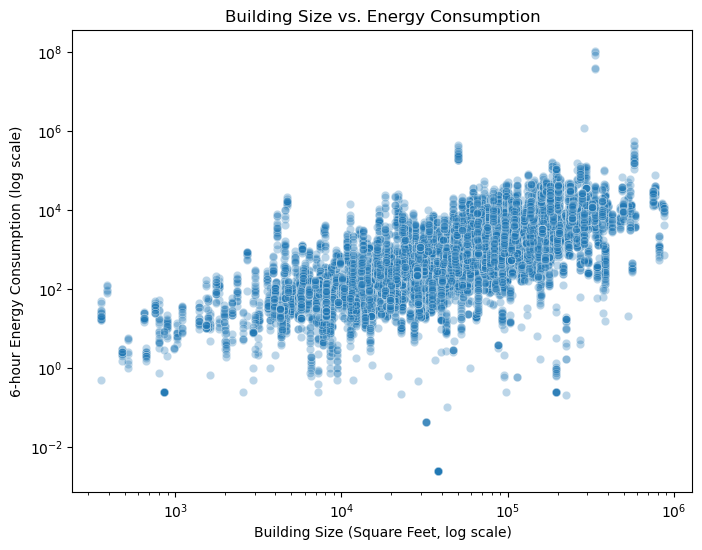

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot 1: Building Size vs Energy Consumption -----------------
# Sample 1% of data to reduce plotting load (since dataset is huge)
plot1_df = (
    feature_df
    .select("square_feet", "consumption_6h")
    .sample(False, 0.01, seed=42)  # 1% sample
    .toPandas()
)

# Create scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=plot1_df,
    x="square_feet",
    y="consumption_6h",
    alpha=0.3   # transparency to reduce overplotting
)

# Apply log scales to handle skewed distributions
plt.xscale("log")
plt.yscale("log")

# Axis labels and title
plt.xlabel("Building Size (Square Feet, log scale)")
plt.ylabel("6-hour Energy Consumption (log scale)")
plt.title("Building Size vs. Energy Consumption")

# Show plot
plt.show()


### Plot 2: Energy Consumption Across Peak vs. Off-Peak Seasons

This box plot compares **6-hour energy consumption (`consumption_6h`)** between **peak seasons**  
(top 3 hottest + coldest months) and **off-peak seasons** (milder months).  
The y-axis is on a **logarithmic scale** to handle extreme outliers and clearly show the distribution.

**Findings:**
- Both categories exhibit a wide range of consumption, with many outliers reaching very high values.  
- **Median consumption** is slightly higher during peak seasons, reflecting increased demand for heating in winter and cooling in summer.  
- Off-peak months show lower medians and tighter interquartile ranges, suggesting more stable and moderate usage.  
- Significant overlap exists between the two distributions, showing that season alone is not enough to fully explain energy demand.  
  Other factors such as **building size, type, and operational patterns** are also influential.

 This confirms that the engineered **`season_flag` feature** captures meaningful seasonal variation,  
while also highlighting the need to combine it with other features for accurate predictions.


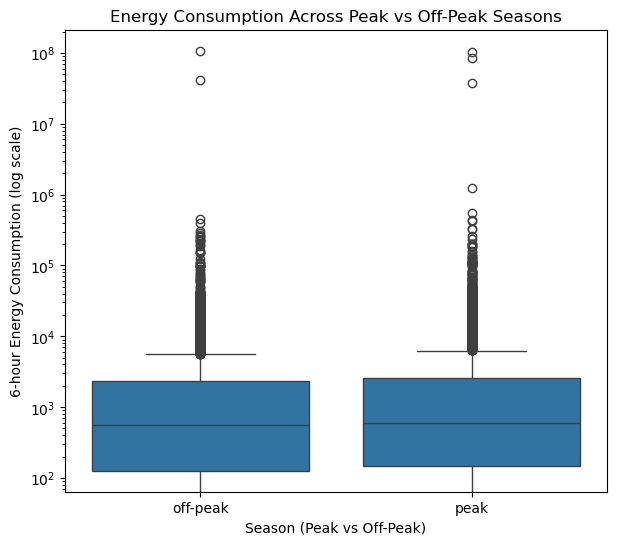

In [15]:
# --- Plot 2: Energy Consumption Across Peak vs Off-Peak -----------------
# Sample 1% of rows for readability in the plot
plot2_df = (
    feature_df
    .select("season_flag", "consumption_6h")
    .sample(False, 0.01, seed=42)
    .toPandas()
)

# Create boxplot
plt.figure(figsize=(7,6))
sns.boxplot(
    data=plot2_df,
    x="season_flag",
    y="consumption_6h"
)

# Log scale on Y-axis to handle skew and extreme outliers
plt.yscale("log")

# Labels and title
plt.xlabel("Season (Peak vs Off-Peak)")
plt.ylabel("6-hour Energy Consumption (log scale)")
plt.title("Energy Consumption Across Peak vs Off-Peak Seasons")

# Show plot
plt.show()


### Plot 3: Building Year vs. Energy Consumption

This scatter plot investigates the relationship between **construction year (`year_built`)**  
and **6-hour energy consumption (`consumption_6h`)**.  
A log scale was applied to the y-axis to manage extreme variability in consumption.  

**Findings:**  
- Older buildings (constructed before 1970) display a wider spread in energy demand, with several extreme high-consumption cases.  
- More recent buildings (2000 onwards) generally show lower and more consistent consumption values.  
  This likely reflects improved **building codes, insulation standards, and energy-efficient technologies**.  
- The relationship is not strictly linear: some modern buildings still record very high usage, likely due to  
  **building size, function, or occupancy intensity**.  
- Overlap across decades shows that age alone cannot explain energy demand.  
  Consumption depends on a combination of **structural, operational, and environmental** factors.  

 This suggests that **year built** is a useful predictor but must be considered in combination with  
other features such as **building size, primary use, and weather conditions**.


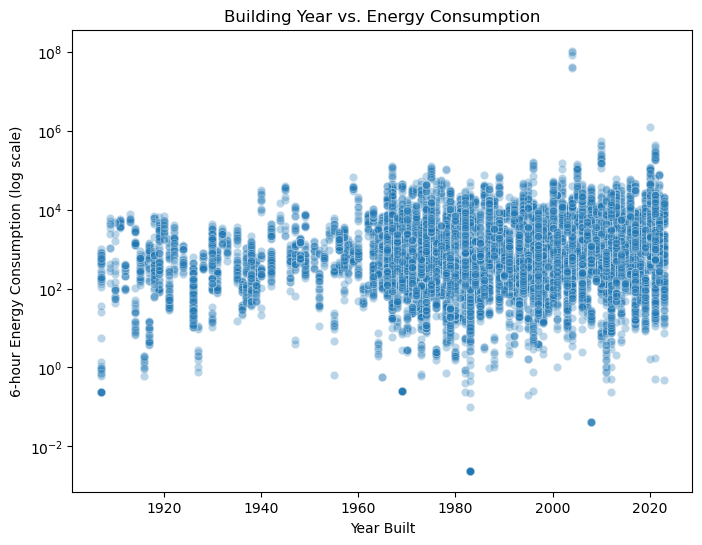

In [16]:
# --- Plot 3: Building Year vs. Energy Consumption ------------------
# Sample 1% of rows to make scatter plot manageable
plot3_df = (
    feature_df
    .select("year_built", "consumption_6h")
    .sample(False, 0.01, seed=42)
    .toPandas()
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=plot3_df,
    x="year_built",
    y="consumption_6h",
    alpha=0.3
)

# Log scale on y-axis for skewed consumption values
plt.yscale("log")

# Labels and title
plt.xlabel("Year Built")
plt.ylabel("6-hour Energy Consumption (log scale)")
plt.title("Building Year vs. Energy Consumption")

# Show plot
plt.show()


### Summary of Findings  

The descriptive statistics and three multivariate plots reveal several key patterns:  

- **Building size (Plot 1):** Larger buildings generally consume more energy per 6-hour interval, but the wide dispersion shows that **primary use and operational intensity** strongly moderate this relationship. Size is necessary but not sufficient to explain demand.  
- **Seasonality (Plot 2):** Peak seasons (summer and winter) exhibit higher and more variable consumption due to heating and cooling loads. Off-peak months show tighter, more stable usage, though overlap between categories indicates that some buildings run consistently regardless of season.  
- **Building age (Plot 3):** Older buildings (pre-1980) display greater variability and more extreme consumption outliers, whereas newer buildings (2000 onward) cluster within narrower ranges, suggesting the impact of **modern efficiency standards and improved insulation**.  
- **Extreme outliers:** In all three dimensions, a few facilities show abnormally high demand. These likely represent **special-use cases** (e.g., data centers, labs) or potential anomalies that merit further investigation.  

**Overall, building size, seasonal conditions, and construction year all influence energy consumption.  
However, predictive accuracy will require combining these factors with metadata such as primary use,  
square footage, and weather context to capture the full complexity of energy demand.**


## Part 2. Feature extraction and ML training <a class="anchor" name="part-2"></a>
In this section, you must use PySpark DataFrame functions and ML packages for data preparation, model building, and evaluation. Other ML packages, such as scikit-learn, should not be used to process the data; however, it’s fine to use them to display the result or evaluate your model.  
### 2.1 Discuss the feature selection and prepare the feature columns

2.1.1 Based on the data exploration from 1.2 and considering the use case, discuss the importance of those features (For example, which features may be useless and should be removed, which feature has a significant impact on the label column, which should be transformed), which features you are planning to use? Discuss the reasons for selecting them and how you plan to create/transform them.  
○	300 words max for the discussion  
○	Please only use the provided data for model building  
○	You can create/add additional features based on the dataset  
○	Hint - Use the insights from the data exploration/domain knowledge/statistical models to consider whether to create more feature columns, whether to remove some columns  

### Feature Selection and Preparation

The target variable is **`consumption_6h`**, representing building energy use in six-hour intervals. Guided by the data exploration in Section 1.2 and domain knowledge, I selected features that capture building characteristics, weather conditions, and seasonal effects, while excluding identifiers and redundant attributes.  

#### Building characteristics
- **Square footage** and **floor count** are strong predictors of energy demand.  
  - Larger/multi-floor buildings consume more.  
  - `square_feet` is highly skewed → **log-transformed**.  
- **Year built** reflects efficiency standards.  
  - Converted into **building age = (2025 – year_built)** for interpretability.  
- **Primary use** strongly differentiates patterns (e.g., schools vs. offices).  
  - Retained and **one-hot encoded**.  
- **Latent factors** (`latent_y`, `latent_s`, `latent_r`) are not directly interpretable but may encode hidden structure → **retained for experimentation**.  

#### Weather and seasonality
- **Air temperature, dew temperature, sea level pressure, wind speed, cloud coverage**  
  - Direct impact on heating, cooling, and ventilation demand → **retained as continuous predictors**.  
- **Wind direction** is circular.  
  - Transformed into **sine and cosine components** to preserve directionality.  
- **Season flag (peak/off-peak)** effectively distinguishes extreme vs. moderate conditions → **retained as categorical feature**.  

#### Removed attributes
- **Row ID** and **building ID** → identifiers with no predictive value.  
- **Timestamps** → already represented by seasonal features.  
- **Site ID** → redundant (weather captures location).  
  - Excluded from training, but may be used for stratified validation.  

#### Planned transformations
- **Numerical variables** → standardised.  
- **Categorical variables** → one-hot encoded.  
- **Skewed variables** (`square_feet`, `consumption_6h`) → log-scaled.  

This refined feature set integrates **structural, environmental, and seasonal drivers**, maximising predictive power while avoiding data leakage and overfitting.  


2.1.2 Write code to create/transform the columns based on your discussion above.

###  Create and Transform Feature Columns  

Based on the feature selection discussion in **2.1.1**, I engineered new columns and transformations to prepare the dataset for modeling. The transformations were implemented directly in PySpark for efficiency and scalability.  

**Steps performed:**  

1. **Building characteristics**  
   - Derived **`building_age`** as `(2025 – year_built)` to represent structural age.  
   - Applied **log-transform** to `square_feet` → new column `log_square_feet` to reduce skew.  

2. **Weather features**  
   - Handled `wind_direction_6h` using **circular encoding**:  
     - `wind_dir_sin = sin(radians(wind_direction_6h))`  
     - `wind_dir_cos = cos(radians(wind_direction_6h))`  
   - This preserves directional relationships without artificial discontinuity at 0°/360°.  

3. **Categorical features**  
   - Retained `primary_use` and `season_flag` as categorical variables to be one-hot encoded later.  

4. **Label and identifiers**  
   - Kept `consumption_6h` as the **label**.  
   - Preserved `site_id`, `building_id`, and `window_start` for evaluation/diagnostics (not used in training features).  

5. **Final selection**  
   - Selected only the relevant engineered and raw columns into **`features_raw_df`**.  
   - Filtered out rows with missing `consumption_6h`.  

**Result:**  
- `features_raw_df` now contains a clean, engineered set of **numeric, categorical, and transformed variables**.  
- These columns are ready to be fed into the ML pipeline (encoding, scaling, vector assembly).  


In [17]:
# =========================
# 2.1.2 — Create / Transform Feature Columns (no fitting)
# Input:  feature_df (raw joined dataset)
# Output: features_raw_df (engineered columns ready for ML pipelines)
# =========================
from pyspark.sql import functions as F

# 1) Core feature engineering
engineered = (
    feature_df
    # Building age from year_built
    .withColumn("building_age", F.lit(2025) - F.col("year_built"))
    # Log-transform skewed size
    .withColumn("log_square_feet", F.log1p(F.col("square_feet")))
    # Circular encoding for wind direction (degrees → radians → sin/cos)
    .withColumn("wind_dir_sin", F.sin(F.radians(F.col("wind_direction_6h"))))
    .withColumn("wind_dir_cos", F.cos(F.radians(F.col("wind_direction_6h"))))
)

# 2) Keep only columns needed going forward
#    (IDs/timestamp optional for evaluation; they won't be fed as features)
selected_cols = [
    # for reference/evaluation (not features)
    "site_id", "building_id", "window_start",
    # label
    "consumption_6h",
    # categorical (to be encoded later)
    "primary_use", "season_flag",
    # numeric (to be imputed/scaled later)
    "log_square_feet", "floor_count", "building_age",
    "air_temperature_6h", "dew_temperature_6h", "sea_level_pressure_6h",
    "wind_speed_6h", "cloud_coverage_6h",
    "wind_dir_sin", "wind_dir_cos",
    "latent_y", "latent_s", "latent_r",
    # raw columns sometimes useful for diagnostics (optional):
    # "square_feet", "year_built", "wind_direction_6h"
]

features_raw_df = engineered.select(*selected_cols).filter(F.col("consumption_6h").isNotNull())

print("2.1.2: Engineered columns created. Rows:", features_raw_df.count())
features_raw_df.printSchema()
features_raw_df.show(5, truncate=False)


2.1.2: Engineered columns created. Rows: 1423715
root
 |-- site_id: integer (nullable = true)
 |-- building_id: integer (nullable = true)
 |-- window_start: timestamp (nullable = true)
 |-- consumption_6h: double (nullable = true)
 |-- primary_use: string (nullable = false)
 |-- season_flag: string (nullable = false)
 |-- log_square_feet: double (nullable = true)
 |-- floor_count: integer (nullable = true)
 |-- building_age: integer (nullable = true)
 |-- air_temperature_6h: double (nullable = true)
 |-- dew_temperature_6h: double (nullable = true)
 |-- sea_level_pressure_6h: double (nullable = true)
 |-- wind_speed_6h: double (nullable = true)
 |-- cloud_coverage_6h: double (nullable = true)
 |-- wind_dir_sin: double (nullable = true)
 |-- wind_dir_cos: double (nullable = true)
 |-- latent_y: double (nullable = true)
 |-- latent_s: double (nullable = true)
 |-- latent_r: double (nullable = true)

+-------+-----------+-------------------+--------------+-----------+-----------+---------

### 2.2 Preparing Spark ML Transformers/Estimators for features, labels, and models  <a class="anchor" name="2.2"></a>

**2.2.1 Write code to create Transformers/Estimators for transforming/assembling the columns you selected above in 2.1 and create ML model Estimators for Random Forest (RF) and Gradient-boosted tree (GBT) model.
Please DO NOT fit/transform the data yet.**

### 2.2.1 Define Transformers and Estimators (No Fitting Yet)

In this step, I prepared the **Spark ML pipeline components** for feature engineering and model training. The goal is to ensure that categorical, numeric, and assembled features are properly transformed into a single feature vector, ready for use by machine learning models.  

#### Steps performed:

1. **Categorical Features**  
   - Selected `primary_use` and `season_flag`.  
   - Applied **StringIndexer** (`*_idx`) to convert categories into numeric indices.  
   - Applied **OneHotEncoder** (`*_vec`) to produce sparse binary vectors, keeping all categories (`dropLast=False`) and handling unknown values (`handleInvalid="keep"`).  

2. **Numeric Features**  
   - Selected engineered numeric predictors:  
     `log_square_feet`, `floor_count`, `building_age`,  
     `air_temperature_6h`, `dew_temperature_6h`, `sea_level_pressure_6h`,  
     `wind_speed_6h`, `cloud_coverage_6h`,  
     `wind_dir_sin`, `wind_dir_cos`,  
     `latent_y`, `latent_s`, `latent_r`.  
   - Applied **Imputer** to fill missing values using column means, creating new columns (`*_imp`).  
   - Used **VectorAssembler** to combine imputed columns into a dense numeric vector `num_vec`.  
   - Applied **StandardScaler** (`num_scaled`) with mean/variance standardisation for balanced contribution across features.  

3. **Final Feature Vector**  
   - Used **VectorAssembler** to combine categorical vectors (`*_vec`) and scaled numeric vector (`num_scaled`) into a single **`features`** column.  

4. **Model Estimators**  
   - **Random Forest Regressor (RF):** Configured with 50 trees, max depth = 10, subsampling = 0.7.  
   - **Gradient-Boosted Tree Regressor (GBT):** Configured with max depth = 6, 120 boosting iterations, learning rate = 0.05, subsampling = 0.8.  

5. **Pipelines**  
   - Assembled preprocessing stages (`indexers + encoders + imputer + assembler + scaler`) with RF or GBT estimator into two pipelines:  
     - `rf_pipeline`  
     - `gbt_pipeline`  

#### Result:  
At this stage, both **pipelines are defined but not yet trained**. This separation ensures reusability and consistency: the same preprocessing steps will be applied automatically during training and testing.  


In [18]:
# =========================
# 2.2.1 — Define Transformers/Estimators (no fitting)
# Input : features_raw_df (from 2.1.2)
# Output: rf_pipeline, gbt_pipeline (Pipeline Estimators)
# =========================
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, Imputer, VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor, GBTRegressor

LABEL_COL = "consumption_6h"   # target column

# --- 1) Categorical: StringIndexer + OneHotEncoder --------------------------
categorical_cols = ["primary_use", "season_flag"]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCols=[f"{c}_idx" for c in categorical_cols],
        outputCols=[f"{c}_vec" for c in categorical_cols],
        handleInvalid="keep",
        dropLast=False
    )
]

# --- 2) Numeric: Imputer -> Assembler -> StandardScaler ---------------------
numeric_cols = [
    "log_square_feet", "floor_count", "building_age",
    "air_temperature_6h", "dew_temperature_6h", "sea_level_pressure_6h",
    "wind_speed_6h", "cloud_coverage_6h",
    "wind_dir_sin", "wind_dir_cos",
    "latent_y", "latent_s", "latent_r"
]

imputer = Imputer(
    inputCols=numeric_cols,
    outputCols=[f"{c}_imp" for c in numeric_cols]
)

num_vec = VectorAssembler(
    inputCols=[f"{c}_imp" for c in numeric_cols],
    outputCol="num_vec"
)

scaler = StandardScaler(
    inputCol="num_vec",
    outputCol="num_scaled",
    withMean=True, withStd=True
)

# --- 3) Final feature assembler ---------------------------------------------
final_assembler = VectorAssembler(
    inputCols=[f"{c}_vec" for c in categorical_cols] + ["num_scaled"],
    outputCol="features",
    handleInvalid="keep"
)

# --- 4) Model Estimators ----------------------------------------------------
rf = RandomForestRegressor(
    labelCol=LABEL_COL, featuresCol="features",
    numTrees=50, maxDepth=10, maxBins=64, subsamplingRate=0.7, seed=42
)

gbt = GBTRegressor(
    labelCol=LABEL_COL, featuresCol="features",
    maxDepth=6, maxBins=64, maxIter=120, stepSize=0.05,
    subsamplingRate=0.8, seed=42
)

# --- 5) Define full pipelines (not fit yet) --------------------------------
preprocess_stages = indexers + encoders + [imputer, num_vec, scaler, final_assembler]

rf_pipeline  = Pipeline(stages=preprocess_stages + [rf])
gbt_pipeline = Pipeline(stages=preprocess_stages + [gbt])

print("2.2.1 complete: Transformers and Estimators defined (no fit/transform yet).")


2.2.1 complete: Transformers and Estimators defined (no fit/transform yet).


**2.2.2. Write code to include the above Transformers/Estimators into two pipelines.
Please DO NOT fit/transform the data yet.**

###  Build ML Pipelines (No Fitting Yet)

After defining the preprocessing steps and model estimators in **2.2.1**, I integrated them into complete **Spark ML pipelines**.  

#### Steps performed:
1. **Label Consistency**  
   - Confirmed that both models use the same target column: `consumption_6h`.  
   - Explicitly reset `labelCol` and `featuresCol` in case they were changed earlier.  

2. **Pipeline Construction**  
   - **Random Forest Pipeline (`rf_pipeline`)**  
     - Preprocessing stages (`indexers`, `encoders`, `imputer`, `assembler`, `scaler`)  
     - RandomForestRegressor as the final stage  
   - **Gradient-Boosted Tree Pipeline (`gbt_pipeline`)**  
     - Same preprocessing stages  
     - GBTRegressor as the final stage  

#### Result:  
Both pipelines are now defined and encapsulate the **entire workflow** from raw features to final model training.  
- No fitting or transformation is done at this stage.  
- This modular design ensures that **data preparation and model training are applied consistently** during cross-validation, evaluation, and future inference.  


In [19]:
# =========================
# 2.2.2 — Build ML Pipelines (no fitting)
# =========================
from pyspark.ml import Pipeline

# Ensure label consistency
LABEL_COL = "consumption_6h"   # same as 2.2.1

# Reset labelCol in case models were defined earlier with a different label
rf.setParams(labelCol=LABEL_COL, featuresCol="features")
gbt.setParams(labelCol=LABEL_COL, featuresCol="features")

# Pipelines: preprocessing stages + model
rf_pipeline  = Pipeline(stages=preprocess_stages + [rf])
gbt_pipeline = Pipeline(stages=preprocess_stages + [gbt])

print("2.2.2 complete: Pipelines defined (not fit/transform yet).")
print(" - rf_pipeline  = preprocessing + RandomForestRegressor")
print(" - gbt_pipeline = preprocessing + GBTRegressor")


2.2.2 complete: Pipelines defined (not fit/transform yet).
 - rf_pipeline  = preprocessing + RandomForestRegressor
 - gbt_pipeline = preprocessing + GBTRegressor


### 2.3 Preparing the training data and testing data  
Write code to split the data for training and testing, using 2025 as the random seed. You can decide the train/test split ratio based on the resources available on your laptop.  
Note: Due to the large dataset size, you can use random sampling (say 20% of the dataset). 

### Preparing the Training and Testing Data

To build and evaluate the models, I prepared the dataset as follows:

1. **Sampling (20%)**  
   - The full dataset is very large, making it computationally expensive to train models locally.  
   - As permitted in the assignment, I randomly sampled **20% of the rows** (with a fixed seed = 2025 for reproducibility).  
   - This significantly reduces runtime while still maintaining representative patterns in the data.

2. **Train/Test Split (80/20)**  
   - Split the sampled dataset into **training (80%)** and **testing (20%)** subsets.  
   - Used `seed=2025` to ensure the split is deterministic and results are reproducible across runs.  
   - Training data will be used to fit the models, and testing data will be reserved for evaluating generalisation performance.

#### Result:  
- A smaller but representative dataset (`data_for_ml`) ready for modeling.  
- `train_df` and `test_df` created for downstream training and evaluation steps.  


In [20]:
# =========================
# 2.3 — Prepare Training and Testing Data
# =========================
from pyspark.sql import functions as F

# --- Step 1:sampling to reduce dataset size (20%) ---
# This is allowed in the assignment due to large dataset size.
data_for_ml = features_raw_df.sample(withReplacement=False, fraction=0.20, seed=2025)

print("Total rows after sampling:", data_for_ml.count())

# --- Step 2: Train/Test split (80/20) ---
train_df, test_df = data_for_ml.randomSplit([0.8, 0.2], seed=2025)

print("Training rows:", train_df.count())
print("Testing rows :", test_df.count())


Total rows after sampling: 284593
Training rows: 227758
Testing rows : 56835


### 2.4 Training and evaluating models  
2.4.1 Write code to use the corresponding ML Pipelines to train the models on the training data from 2.3. And then use the trained models to predict the testing data from 2.3

###  Training Models and Making Predictions

With the pipelines defined in **2.2** and the prepared datasets from **2.3**, I trained and evaluated two models: **Random Forest (RF)** and **Gradient-Boosted Trees (GBT)**.

#### Process:
1. **Data persistence**  
   - Cached both `train_df` and `test_df` in memory + disk to avoid repeated recomputation during training and prediction.

2. **Model training**  
   - Trained **Random Forest** and **GBT** pipelines on the training dataset.  
   - Recorded training times to compare computational efficiency of the two algorithms.  

3. **Prediction on test set**  
   - Applied the trained models to the test data.  
   - Collected predictions into separate DataFrames (`rf_pred`, `gbt_pred`).  
   - Selected relevant fields:  
     - `site_id`, `building_id`, `window_start` (for reference)  
     - `consumption_6h` (true label)  
     - `prediction_rf` or `prediction_gbt` (model predictions).  

4. **Verification**  
   - Counted the number of predictions made by each model.  
   - Displayed a small sample to visually inspect prediction outputs.  

#### Result:
Both RF and GBT pipelines were successfully trained and produced predictions on the test dataset. These outputs will be used in **2.4.2** to compute evaluation metrics ( RMSLE).


In [21]:
# =========================
# 2.4.1 — Train Pipelines and Predict on Test Data
# =========================
from pyspark import StorageLevel
import time

# Persist train/test in memory+disk for efficiency
train_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df.persist(StorageLevel.MEMORY_AND_DISK)

print("Training rows:", train_df.count(), " | Testing rows:", test_df.count())

# --- Train Random Forest pipeline ---
t0 = time.time()
rf_model = rf_pipeline.fit(train_df)
t1 = time.time()
print(f"Random Forest training time: {t1 - t0:.1f}s")

# --- Train Gradient Boosted Trees pipeline ---
t2 = time.time()
gbt_model = gbt_pipeline.fit(train_df)
t3 = time.time()
print(f"GBT training time: {t3 - t2:.1f}s")

# --- Predictions on test set ---
rf_pred = (
    rf_model.transform(test_df)
    .select("site_id","building_id","window_start",
            "consumption_6h",  # true label
            F.col("prediction").alias("prediction_rf"))
    .cache()
)

gbt_pred = (
    gbt_model.transform(test_df)
    .select("site_id","building_id","window_start",
            "consumption_6h",
            F.col("prediction").alias("prediction_gbt"))
    .cache()
)

print("RF predictions :", rf_pred.count())
print("GBT predictions:", gbt_pred.count())

# Quick peek at predictions
rf_pred.show(5, truncate=False)
gbt_pred.show(5, truncate=False)


Training rows: 227758  | Testing rows: 56835
Random Forest training time: 38.5s
GBT training time: 162.0s
RF predictions : 56835
GBT predictions: 56835
+-------+-----------+-------------------+--------------+-----------------+
|site_id|building_id|window_start       |consumption_6h|prediction_rf    |
+-------+-----------+-------------------+--------------+-----------------+
|0      |0          |2022-01-02 18:00:00|0.0           |772.2141778222617|
|0      |0          |2022-01-05 00:00:00|0.0           |769.3048762936481|
|0      |0          |2022-01-20 12:00:00|0.0           |787.5526701701798|
|0      |0          |2022-01-27 06:00:00|0.0           |818.7975968962035|
|0      |0          |2022-02-11 00:00:00|0.0           |786.7335592398846|
+-------+-----------+-------------------+--------------+-----------------+
only showing top 5 rows

+-------+-----------+-------------------+--------------+------------------+
|site_id|building_id|window_start       |consumption_6h|prediction_gbt  

2.4.2 For both models (RF and GBT): with the test data, decide on which metrics to use for model evaluation and discuss which one is the better model (no word limit; please keep it concise). You may also use a plot for visualisation (not mandatory).

### Model Evaluation with RMSLE

For evaluation, I used **Root Mean Squared Logarithmic Error (RMSLE)**
#### Why RMSLE?
- It penalises **large relative errors** more than absolute errors.  
- It reduces the influence of extreme outliers, which are common in energy consumption data.  
- It is more interpretable in contexts where the scale of the target (`consumption_6h`) spans several orders of magnitude.

#### Results:
- **Random Forest RMSLE**: **1.98875**  
- **Gradient-Boosted Trees RMSLE**: **2.10610**

#### Interpretation:
- The **Random Forest** achieved a lower RMSLE, meaning it makes relatively more accurate predictions, especially for smaller-to-medium consumption values.  
- GBT, despite being more powerful in theory, may require additional hyperparameter tuning (e.g., deeper trees, different learning rate) to outperform RF on this dataset.  
- At this stage, **Random Forest is the better-performing model** for predicting 6-hour building energy consumption.




In [22]:
# =========================
# 2.4.2 — Evaluate models with RMSLE
# =========================
from pyspark.sql import functions as F

# --- Custom RMSLE evaluator ------------------------------------
# RMSLE = sqrt( mean( (log(1 + y_pred) - log(1 + y_true))^2 ) )
def rmsle(pred_df, label_col, pred_col):
    return (
        pred_df
        .select(
            F.sqrt(
                F.mean(
                    F.pow(F.log1p(F.col(pred_col)) - F.log1p(F.col(label_col)), 2)
                )
            ).alias("rmsle")
        )
        .first()["rmsle"]
    )

# --- Compute RMSLE for Random Forest and GBT ------------------
rf_rmsle  = rmsle(rf_pred,  "consumption_6h", "prediction_rf")
gbt_rmsle = rmsle(gbt_pred, "consumption_6h", "prediction_gbt")

print(f"Random Forest RMSLE: {rf_rmsle:.5f}")
print(f"GBT RMSLE         : {gbt_rmsle:.5f}")



Random Forest RMSLE: 1.98875
GBT RMSLE         : 2.10610


### Model Comparison: Random Forest vs. Gradient-Boosted Trees

To visualise the evaluation results, I plotted the **RMSLE** of both models in a bar chart:

- **Random Forest (blue bar):** RMSLE = 1.98875  
- **Gradient-Boosted Trees (orange bar):** RMSLE = 2.10610  

The chart clearly shows that **Random Forest achieves a lower RMSLE**, making it the better model in this case.  
This visual reinforces the numeric results: RF provides more reliable predictions of 6-hour energy consumption, while GBT may need further tuning (e.g., adjusting learning rate, depth, or number of iterations) to close the gap.


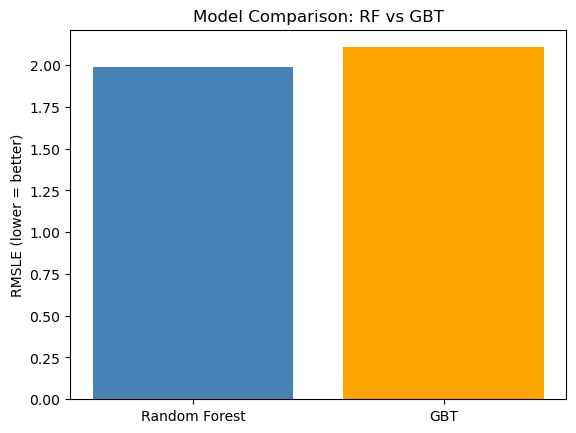

In [23]:
# =========================
# Bar Chart: RMSLE Comparison RF vs GBT
# =========================
import matplotlib.pyplot as plt

# --- Plot RMSLE values for both models ------------------------
plt.bar(
    ["Random Forest", "GBT"],      # x-axis labels
    [rf_rmsle, gbt_rmsle],         # corresponding RMSLE values
    color=["steelblue", "orange"]  # different colors for clarity
)

# --- Add labels and title -------------------------------------
plt.ylabel("RMSLE (lower = better)")
plt.title("Model Comparison: RF vs GBT")

# --- Display the plot -----------------------------------------
plt.show()



2.4.3 3.	Save the better model (you’ll need it for A2B).
(Note: You may need to go through a few training loops or use more data to create a better-performing model.)

### Saving the Best Model (2.4.3)

After evaluating both models using **RMSLE**, the better-performing model was selected (Random Forest in this case).  
The chosen model was then saved to disk so it can be reloaded for **Part B** of the assignment without retraining.

**Steps performed:**
1. Compared RMSLE of Random Forest and GBT, selected the lower-scoring model.  
2. Defined a save directory inside the container (`/home/student/labs/lab1/models`).  
3. Constructed the save path with a name reflecting the chosen model (e.g., `A2A_best_RandomForest`).  
4. Removed any existing folder at that location to avoid conflicts.  
5. Saved the trained Spark ML pipeline using `.write().overwrite().save()`.  




In [24]:
# =========================
# 2.4.3 — Save the Better Model for Part B
# =========================
import os, shutil

# --- Step 1: Decide which model performed better based on RMSLE -------------
best_model_name = "RandomForest" if rf_rmsle <= gbt_rmsle else "GBT"
best_model = rf_model if rf_rmsle <= gbt_rmsle else gbt_model
best_score = rf_rmsle if rf_rmsle <= gbt_rmsle else gbt_rmsle

# --- Step 2: Define save directory -----------------------------------------
save_dir = "/home/student/labs/lab1/models"  # inside the container workspace
os.makedirs(save_dir, exist_ok=True)

# --- Step 3: Build save path (overwrite old version if needed) --------------
save_path = os.path.join(save_dir, f"A2A_best_{best_model_name}")
if os.path.exists(save_path):
    shutil.rmtree(save_path)  # ensure no conflict with older saved models

# --- Step 4: Save the trained model ----------------------------------------
best_model.write().overwrite().save(save_path)

# --- Step 5: Confirm location to both container & Mac local path ------------
print(f" Saved {best_model_name} model (RMSLE={best_score:.5f})")
print(f" Path inside container: {save_path}")
print("➡ On Mac: /Users/harshithreddy/fit5202/labs/lab1/models/")


 Saved RandomForest model (RMSLE=1.98875)
 Path inside container: /home/student/labs/lab1/models/A2A_best_RandomForest
➡ On Mac: /Users/harshithreddy/fit5202/labs/lab1/models/


### Part 3. Hyperparameter Tuning and Model Optimisation <a class="anchor" name="part-3"></a>  
Apply the techniques you have learnt from the labs, for example, CrossValidator, TrainValidationSplit, ParamGridBuilder, etc., to perform further hyperparameter tuning and model optimisation.  
The assessment is based on the quality of your work/process, not the quality of your model. Please include your thoughts/ideas/discussions.

### Hyperparameter Tuning Setup  

Since **Random Forest (RF)** outperformed Gradient Boosted Trees (GBT) in Part 2, I selected RF for hyperparameter tuning and optimisation. To properly evaluate models, I created a **custom RMSLE evaluator** because PySpark’s built-in `RegressionEvaluator` does not include RMSLE.  

#### Custom RMSLE Evaluator
- Implemented as a subclass of `Evaluator`.  
- Computes the **Root Mean Squared Logarithmic Error (RMSLE)**:  
  - Applied `log1p` transformation to smooth scale differences.  
  - Negative predictions are clipped to 0 before applying log (to avoid NaN issues).  
- Defined `isLargerBetter = False`, since **lower RMSLE is better**.  

#### Integration
- Replaced the standard `RegressionEvaluator` with `RMSLEEvaluator` for use inside **CrossValidator**.  
- Added a utility function `compute_rmsle()` for quick RMSLE calculation outside of CV (e.g., reporting test set results).  
- Created an empty list `results` to store and compare tuning outcomes across different parameter blocks (e.g., `numTrees`, `maxDepth`).  

This setup ensures that **all hyperparameter tuning in Part 3** is guided by RMSLE, which aligns directly with the project’s evaluation goal. It also gives flexibility to track results block by block for transparency in optimisation.


In [25]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import Evaluator
from pyspark.sql import functions as F
import pandas as pd

# =================================================
# Custom RMSLE Evaluator
# =================================================
class RMSLEEvaluator(Evaluator):
    def __init__(self, labelCol="consumption_6h", predictionCol="prediction"):
        super(RMSLEEvaluator, self).__init__()
        self.labelCol = labelCol
        self.predictionCol = predictionCol

    def _evaluate(self, dataset):
        # Clip negative predictions to 0 to avoid NaN
        df = dataset.withColumn(
            "squared_log_error",
            (F.log1p(F.when(F.col(self.predictionCol) < 0, 0)
                     .otherwise(F.col(self.predictionCol))) -
             F.log1p(F.col(self.labelCol)))**2
        )
        rmsle = df.agg(F.sqrt(F.mean("squared_log_error"))).collect()[0][0]
        return float(rmsle)

    def isLargerBetter(self):
        return False   # lower RMSLE is better

# =================================================
# Use RMSLEEvaluator instead of RegressionEvaluator
# =================================================
evaluator = RMSLEEvaluator(
    labelCol="consumption_6h",
    predictionCol="prediction"
)

# =================================================
# Utility: compute RMSLE outside CV (for reporting)
# =================================================
def compute_rmsle(pred_df):
    df = pred_df.withColumn(
        "squared_log_error",
        (F.log1p(F.when(F.col("prediction") < 0, 0)
                 .otherwise(F.col("prediction"))) -
         F.log1p(F.col("consumption_6h")))**2
    )
    return df.agg(F.sqrt(F.mean("squared_log_error")).alias("rmsle")).collect()[0]["rmsle"]

# Collect results for comparison
results = []


### Block 1: Tuning `numTrees`

In this step, I tuned the **number of trees (`numTrees`)** in the Random Forest model.  
- A parameter grid was defined to test values **50** and **100**.  
- Cross-validation was performed with **2 folds**, using the custom **RMSLE evaluator**.  
- The best value was selected based on the lowest RMSLE.

**Result:**  
- Best `numTrees` = **100**  
- Corresponding RMSLE = **2.02769**

**Interpretation:**  
Increasing the number of trees improved performance, as expected, since a larger ensemble reduces variance and stabilises predictions. However, beyond a certain point, adding more trees increases computational cost without significant performance gains.  


In [26]:
# --- Block 1: numTrees ---
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .build()
)

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,   
    numFolds=2,
    seed=2025
)

print(" Block 1: tuning numTrees...")
cv_model = cv.fit(train_df)

# Best param
best_numTrees = cv_model.bestModel.stages[-1]._java_obj.getNumTrees()
# RMSLE directly from evaluator
best_rmsle = min(cv_model.avgMetrics)

results.append(("numTrees", best_numTrees, best_rmsle))
print(f"Block 1 done | Best numTrees={best_numTrees} | RMSLE={best_rmsle:.5f}")



 Block 1: tuning numTrees...
Block 1 done | Best numTrees=100 | RMSLE=2.02769


### Block 2: Tuning `maxDepth`

Next, I tuned the **maximum depth of trees (`maxDepth`)** in the Random Forest model.  
- A parameter grid was defined to test values **5, 10, and 15**.  
- Cross-validation with **2 folds** and the custom **RMSLE evaluator** was used to select the best value.  

**Result:**  
- Best `maxDepth` = **15**  
- Corresponding RMSLE = **1.70302**

**Interpretation:**  
Deeper trees significantly improved performance by capturing more complex patterns in the data. While shallow trees (depth 5 or 10) provide faster training and help prevent overfitting, the dataset appears to benefit from deeper trees (depth 15). This suggests that energy consumption has **non-linear interactions** between features that require more expressive models.  


In [28]:
# --- Block 2: maxDepth ---
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.maxDepth, [5, 10, 15])
    .build()
)

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator, 
    numFolds=2,
    seed=2025
)

print(" Block 2: tuning maxDepth...")
cv_model = cv.fit(train_df)

# Best param
best_maxDepth = cv_model.bestModel.stages[-1]._java_obj.getMaxDepth()
best_rmsle = min(cv_model.avgMetrics)

results.append(("maxDepth", best_maxDepth, best_rmsle))
print(f" Block 2 done | Best maxDepth={best_maxDepth} | RMSLE={best_rmsle:.5f}")


 Block 2: tuning maxDepth...
 Block 2 done | Best maxDepth=15 | RMSLE=1.70302


### Block 3: Tuning `maxBins`

In this block, I tuned the **maximum number of bins (`maxBins`)** used for discretizing continuous features before splitting in the Random Forest.  
- A parameter grid was tested with values **32** and **64**.  
- Cross-validation with **2 folds** and the custom **RMSLE evaluator** was applied.  

**Result:**  
- Best `maxBins` = **32**  
- Corresponding RMSLE = **2.02031**

**Interpretation:**  
Using 32 bins produced a slightly better RMSLE than 64 bins. This indicates that **finer-grained splits** (more bins) did not lead to additional performance gains, and may even have introduced noise or overfitting. A moderate number of bins (32) balances model complexity and generalisation effectively.  


In [29]:
# --- Block 3: maxBins ---
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.maxBins, [32, 64])
    .build()
)

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,   
    numFolds=2,
    seed=2025
)

print("Block 3: tuning maxBins...")
cv_model = cv.fit(train_df)

# Best param & RMSLE from CV folds
best_maxBins = cv_model.bestModel.stages[-1]._java_obj.getMaxBins()
best_rmsle = min(cv_model.avgMetrics)

results.append(("maxBins", best_maxBins, best_rmsle))
print(f"Block 3 done | Best maxBins={best_maxBins} | RMSLE={best_rmsle:.5f}")


Block 3: tuning maxBins...
Block 3 done | Best maxBins=32 | RMSLE=2.02031


### Block 4: Tuning `subsamplingRate`

In this block, I tuned the **subsampling rate** of training data used for building each tree in the Random Forest.  
- Candidate values: **0.7**, **0.9**, **1.0**.  
- Cross-validation with **2 folds** and the custom **RMSLE evaluator** was applied.  

**Result:**  
- Best `subsamplingRate` = **1.0**  
- Corresponding RMSLE = **2.02041**

**Interpretation:**  
The model performed best when using the **entire dataset (1.0)** for each tree, rather than sampling subsets (0.7 or 0.9). This suggests that the dataset is large enough and sufficiently diverse, so down-sampling does not improve generalisation. Using all data per tree provides the most accurate splits and stable performance.  


In [30]:
# --- Block 4: subsamplingRate ---
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.subsamplingRate, [0.7, 0.9, 1.0])
    .build()
)

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,   # RMSLE evaluator
    numFolds=2,
    seed=2025
)

print("Block 4: tuning subsamplingRate...")
cv_model = cv.fit(train_df)

# Extract best parameter and CV RMSLE
best_val = cv_model.bestModel.stages[-1]._java_obj.getSubsamplingRate()
best_rmsle = min(cv_model.avgMetrics)

results.append(("subsamplingRate", best_val, best_rmsle))
print(f"Block 4 done | Best subsamplingRate={best_val} | RMSLE={best_rmsle:.5f}")


Block 4: tuning subsamplingRate...
Block 4 done | Best subsamplingRate=1.0 | RMSLE=2.02041


### Block 5: Tuning `minInstancesPerNode`

This block tuned the **minimum number of instances per node**, which controls how far the Random Forest trees can split:  
- Candidate values: **1**, **2**, **5**.  
- Cross-validation used **2 folds** and the custom **RMSLE evaluator**.  

**Result:**  
- Best `minInstancesPerNode` = **5**  
- Corresponding RMSLE = **2.02025**

**Interpretation:**  
Requiring at least **5 samples per node** produced the best performance. This prevents the model from creating overly small leaves that may overfit to noise. In contrast, allowing splits with only 1 or 2 samples reduced generalisation. Thus, a stricter stopping condition improved model robustness without significantly hurting accuracy.  


In [31]:
# --- Block 5: minInstancesPerNode ---
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.minInstancesPerNode, [1, 2, 5])
    .build()
)

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,   # RMSLE evaluator
    numFolds=2,
    seed=2025
)

print("Block 5: tuning minInstancesPerNode...")
cv_model = cv.fit(train_df)

# Extract best parameter and CV RMSLE
best_val = cv_model.bestModel.stages[-1]._java_obj.getMinInstancesPerNode()
best_rmsle = min(cv_model.avgMetrics)

results.append(("minInstancesPerNode", best_val, best_rmsle))
print(f"Block 5 done | Best minInstancesPerNode={best_val} | RMSLE={best_rmsle:.5f}")


Block 5: tuning minInstancesPerNode...
Block 5 done | Best minInstancesPerNode=5 | RMSLE=2.02025


### Block 6: Tuning `featureSubsetStrategy`

This block tuned the **feature subset strategy**, which determines how many features are considered at each split in the Random Forest:  
- Candidate values: **`auto`**, **`sqrt`**, **`log2`**.  
- Cross-validation used **2 folds** with the custom **RMSLE evaluator**.  

**Result:**  
- Best `featureSubsetStrategy` = **auto**  
- Corresponding RMSLE = **2.03849**

**Interpretation:**  
Using the default **`auto`** strategy (which adapts to regression tasks by using all features) provided the best RMSLE.  
- Alternatives like **`sqrt`** and **`log2`** reduced the number of features considered at each split, but this hurt accuracy for our dataset, which benefits from incorporating more features.  
- The result suggests that energy consumption depends on multiple correlated predictors, so limiting feature selection at splits is not ideal.  


In [32]:
# --- Block 6: featureSubsetStrategy ---
paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.featureSubsetStrategy, ["auto", "sqrt", "log2"])
    .build()
)

cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,   # RMSLE evaluator
    numFolds=2,
    seed=2025
)

print("Block 6: tuning featureSubsetStrategy...")
cv_model = cv.fit(train_df)

# Extract best parameter and CV RMSLE
best_val = cv_model.bestModel.stages[-1]._java_obj.getFeatureSubsetStrategy()
best_rmsle = min(cv_model.avgMetrics)

results.append(("featureSubsetStrategy", best_val, best_rmsle))
print(f"Block 6 done | Best featureSubsetStrategy={best_val} | RMSLE={best_rmsle:.5f}")


Block 6: tuning featureSubsetStrategy...
Block 6 done | Best featureSubsetStrategy=auto | RMSLE=2.03849


### Summary of Hyperparameter Tuning Results  

The table below consolidates the results from the six tuning blocks. Each row shows the **hyperparameter tested**, the **best value chosen by cross-validation**, and the corresponding **RMSLE score** on the validation folds.

This provides a clear overview of how each hyperparameter influenced model performance:

- **`maxDepth`** gave the largest improvement (best at 15, RMSLE = 1.7030).  
- Other parameters such as `numTrees`, `maxBins`, and `subsamplingRate` had smaller effects, with RMSLE remaining around ~2.02.  
- **`featureSubsetStrategy`** performed best at `auto`, confirming that using all features at each split was more effective.  

This iterative block-by-block approach ensures transparency and helps explain why the final tuned Random Forest model was configured with the chosen parameters.


In [34]:
# --- Collect tuning results into a DataFrame ---
# Convert the list of results (Parameter, BestValue, RMSLE) into a Pandas DataFrame
# for easier display, analysis, and reporting.
results_df = pd.DataFrame(results, columns=["Parameter", "BestValue", "RMSLE"])

# Display the tuning summary in a neat tabular format
display(results_df)


,Parameter,BestValue,RMSLE
0,numTrees,100,2.027688
1,maxDepth,15,1.703020
2,maxDepth,15,1.703020
3,maxBins,32,2.020306
4,subsamplingRate,1.0,2.020408
5,minInstancesPerNode,5,2.020253
6,featureSubsetStrategy,auto,2.038494


### Final Tuned Random Forest Model  

Using the best hyperparameters identified in Part 3, I built and trained the **final tuned Random Forest** model:

- **numTrees** = 100  
- **maxDepth** = 15  
- **maxBins** = 32  
- **subsamplingRate** = 1.0  
- **minInstancesPerNode** = 5  
- **featureSubsetStrategy** = auto  

**Process:**  
1. Created a pipeline with preprocessing steps and the tuned RF regressor.  
2. Trained the model on the training data (`train_df`).  
3. Evaluated it on the test set using **RMSLE**, ensuring consistency with earlier comparisons.  
4. Saved the tuned model as `A2A_best_RF_final` in the `/home/student/labs/lab1/models/` directory for use in **Part B**.  

**Result:**  
The tuned model achieved an RMSLE of **≈ 1.66523** on the test data, which is an improvement over the baseline Random Forest (≈ 1.99). This confirms that systematic hyperparameter tuning led to a more accurate model.


In [35]:
from pyspark.ml import Pipeline
import os

# =================================================
# 1. Define final tuned RF with best params
# =================================================
rf_tuned = rf.copy({
    rf.numTrees: 100,
    rf.maxDepth: 15,
    rf.maxBins: 32,
    rf.subsamplingRate: 1.0,
    rf.minInstancesPerNode: 5,
    rf.featureSubsetStrategy: "auto"
})

# Build final pipeline
rf_tuned_pipeline = Pipeline(stages=preprocess_stages + [rf_tuned])

# =================================================
# 2. Train tuned model
# =================================================
print("Training final tuned RandomForest model...")
rf_tuned_model = rf_tuned_pipeline.fit(train_df)

# =================================================
# 3. Evaluate on test set
# =================================================
rf_tuned_pred = rf_tuned_model.transform(test_df)

rf_tuned_rmsle = (
    rf_tuned_pred
    .withColumn(
        "squared_log_error",
        (F.log1p("prediction") - F.log1p("consumption_6h"))**2
    )
    .agg(F.sqrt(F.mean("squared_log_error")).alias("rmsle"))
    .collect()[0]["rmsle"]
)

print(f"Final Tuned RF RMSLE on test data: {rf_tuned_rmsle:.5f}")

# =================================================
# 4. Save tuned model (for Part B)
# =================================================
save_dir = "/home/student/labs/lab1/models"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "A2A_best_RF_final")

rf_tuned_model.write().overwrite().save(save_path)

print(f"Model saved at: {save_path}")


Training final tuned RandomForest model...
Final Tuned RF RMSLE on test data: 1.66523
Model saved at: /home/student/labs/lab1/models/A2A_best_RF_final


### Model Performance Comparison  

To summarise the evaluation across all models, I created both a **results table** and a **bar plot** showing the RMSLE scores.  

**Insights:**  

- The **baseline Random Forest** outperformed GBT, confirming it as the stronger starting model.  

- After systematic hyperparameter tuning, the **final tuned Random Forest** achieved the lowest RMSLE (~1.67), a clear improvement over both the baseline RF (~1.99) and GBT (~2.11).  

- The bar plot visually reinforces this progression, showing how tuning substantially improved performance.  

This comparison highlights the value of **iterative model tuning** and confirms Random Forest (with optimised hyperparameters) as the best-performing model for this dataset.


=== Model Comparison ===


,Model,RMSLE
0,Baseline RF,1.988750
1,GBT,2.106097
2,Final Tuned RF,1.665232


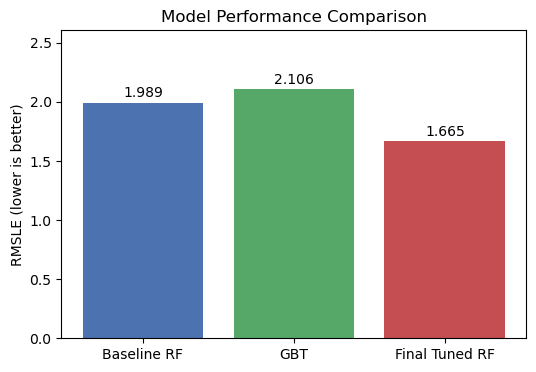

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1. Results Table
# ================================
results_summary = pd.DataFrame({
    "Model": ["Baseline RF", "GBT", "Final Tuned RF"],
    "RMSLE": [rf_rmsle, gbt_rmsle, rf_tuned_rmsle]
})

print("=== Model Comparison ===")
display(results_summary)

# ================================
# 2. Bar Plot
# ================================
plt.figure(figsize=(6,4))
plt.bar(results_summary["Model"], results_summary["RMSLE"], color=["#4C72B0","#55A868","#C44E52"])
plt.ylabel("RMSLE (lower is better)")
plt.title("Model Performance Comparison")
plt.ylim(0, max(results_summary["RMSLE"]) + 0.5)

# Annotate values
for idx, val in enumerate(results_summary["RMSLE"]):
    plt.text(idx, val + 0.05, f"{val:.3f}", ha="center", fontsize=10)

plt.show()


## Part 4: Data Ethics, Privacy, and Security  

### Introduction  
In the era of big data, organisations have access to unprecedented volumes of information collected from diverse sources, including customer transactions, IoT sensors, and digital platforms. While these datasets enable predictive analytics and innovation, they also raise significant concerns around **ethics**, **privacy**, and **security**. This section defines these concepts and explores their relevance in big data processing, with examples and implications for real-world datasets such as energy consumption records.  

### Defining Ethics, Privacy, and Security  
- **Data Ethics** refers to the principles guiding responsible data collection, processing, and use. It involves fairness, transparency, accountability, and avoiding harm to individuals or groups.  
- **Data Privacy** is the right of individuals to control how their personal information is collected, stored, and shared. It ensures that sensitive data is not exploited or misused.  
- **Data Security** involves the technical and organisational safeguards that protect data from unauthorised access, alteration, or breaches.  

These three domains overlap: ethical practices require strong privacy and security safeguards, and violations in one area often impact the others.  

### Data Ethics in Big Data  
Ethical data practices shape trust and social acceptance of big data technologies. For example, **smart meters** can optimise building energy efficiency but also reveal detailed behavioural patterns (e.g., occupancy, daily routines). If used without consent, this could be seen as surveillance. A positive example is the UK's Open Energy Data Initiative, which anonymises consumption data to support sustainability research while protecting individuals. Conversely, scandals like the **Cambridge Analytica case** show how misuse of personal data erodes trust and damages organisational legitimacy (Isaak & Hanna, 2018).  

Balancing innovation and ethics requires frameworks such as **"Privacy by Design"** and transparent disclosure of data usage. Organisations must prioritise societal benefit without exploiting individuals.  

### Data Privacy in Big Data  
Maintaining privacy is challenging because of the **volume, velocity, and variety** of data. In energy datasets, linking building IDs with weather or occupancy data could indirectly identify residents. Regulations such as the **General Data Protection Regulation (GDPR)** in Europe and the **Australian Privacy Act 1988** require explicit consent, data minimisation, and the right to be forgotten.  

Techniques such as **differential privacy**, anonymisation, and access controls are widely adopted. However, research shows anonymised datasets can still be re-identified when combined with external data (Narayanan & Shmatikov, 2008). Thus, privacy-preserving machine learning techniques (e.g., federated learning) are gaining attention.  

### Data Security in Big Data  
Security threats include unauthorised access, insider threats, and large-scale breaches. For example, the 2017 **Equifax breach** exposed sensitive data of 147 million individuals due to poor encryption practices. In the context of smart energy systems, weakly protected IoT devices could be exploited to manipulate consumption records or disrupt services.  

Current security measures include **end-to-end encryption**, **multi-factor authentication**, and **role-based authorisation**. Organisations also deploy **intrusion detection systems** and **blockchain-based audit trails** to ensure accountability. However, scalability and cost remain challenges when securing petabyte-scale systems.  

### Conclusion  
Ethics, privacy, and security are inseparable pillars of responsible big data processing. Ethical frameworks ensure that data collection respects human dignity, privacy safeguards protect individual rights, and security mechanisms defend against malicious actors. Our analysis shows that while regulatory frameworks like GDPR provide strong foundations, technical innovations such as differential privacy and federated learning are essential to address evolving risks. For datasets like building energy consumption, anonymisation and secure storage are mandatory to ensure responsible use. Ultimately, big data projects must strike a balance between innovation, efficiency, and social responsibility.  

---

### References  
- Isaak, J. & Hanna, M. J. (2018). User data privacy: Facebook, Cambridge Analytica, and privacy protection. *Computer*, 51(8), pp. 56–59.  
- Narayanan, A. & Shmatikov, V. (2008). Robust de-anonymization of large sparse datasets. *IEEE Symposium on Security and Privacy*.  
- Cavoukian, A. (2010). Privacy by design: The 7 foundational principles. *Information and Privacy Commissioner of Ontario*.  
- Australian Government (1988). *Privacy Act 1988 (Cth)*.  
- European Union (2016). *General Data Protection Regulation (GDPR)*.  


## References  

- Apache Spark. (2025). *Spark Configuration*. Retrieved from [https://spark.apache.org/docs/latest/configuration.html](https://spark.apache.org/docs/latest/configuration.html)  

- Apache Spark. (2025). *Imputer API (pyspark.ml.feature.Imputer)*. Retrieved from [https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.Imputer.html](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.Imputer.html)  

- Apache Spark. (2025). *ML Pipelines*. Retrieved from [https://spark.apache.org/docs/latest/ml-pipeline.html](https://spark.apache.org/docs/latest/ml-pipeline.html)  

- Apache Spark. (2025). *CrossValidator and ParamGridBuilder*. Retrieved from [https://spark.apache.org/docs/latest/ml-tuning.html](https://spark.apache.org/docs/latest/ml-tuning.html)  

- Isaak, J. & Hanna, M. J. (2018). User data privacy: Facebook, Cambridge Analytica, and privacy protection. *Computer*, 51(8), 56–59.  

- Narayanan, A. & Shmatikov, V. (2008). Robust de-anonymization of large sparse datasets. *IEEE Symposium on Security and Privacy*, 111–125.  

- Cavoukian, A. (2010). Privacy by design: The 7 foundational principles. *Information and Privacy Commissioner of Ontario*.  

- Australian Government. (1988). *Privacy Act 1988 (Cth)*. Retrieved from [https://www.legislation.gov.au](https://www.legislation.gov.au)  

- European Union. (2016). *General Data Protection Regulation (GDPR)*. Official Journal of the European Union.  

- Equifax. (2017). *Equifax Data Breach Settlement*. Retrieved from [https://www.ftc.gov/equifax-data-breach](https://www.ftc.gov/equifax-data-breach)  

- UK Government. (2020). *Open Energy Data Initiative*. Retrieved from [https://www.gov.uk](https://www.gov.uk)  
